In [ ]:
# Paso 0: Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importar Kaggle
import kagglehub

In [17]:
import pandas as pd
df=pd.read_excel("/base.xlsx")
df.head()

,Asesor,Cliente ajustado,Marca,Articulo,6-2025,7-2025,8-2025,9-2025,10-2025,11-2025,12-2025,1-2026,2-2026,3-2026,4-2026,5-2026
0,ADMINISTRACION,Cliente 1,SPS,9994672 96535081 SPS Tijera Delantera Izquierd...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,ADMINISTRACION,Cliente 2,SPS,9999978 KR12-39-040 SPS SOPORTE MOTOR TRASERO ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,ADMINISTRACION,Cliente 2,SPS,9999989 KD45-39-060C SPS SOPORTE MOTOR DERECHO...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,ADMINISTRACION,Cliente 2,SPS,9999990 BJS7-39-070 SPS SOPORTE MOTOR IZQUIERD...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,ADMINISTRACION,Cliente 2,SPS,9999993 K123-39-040B SPS SOPORTE MOTOR TRASERO...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,-1.0


# Task
The user has provided a DataFrame named `df` containing sales or demand data across different months (6-2025 to 5-2026), along with categorical features like 'Asesor', 'Cliente ajustado', 'Marca', and 'Articulo'. The goal is to analyze this dataset to define a project construct for a forecasting task. This involves understanding the DataFrame's structure, identifying key variables, proposing suitable machine learning models, and outlining their advantages and disadvantages.

## Analyze DataFrame Structure

### Subtask:
Examine the `df` DataFrame to understand its columns, data types, and the nature of the data, especially the date-based columns, to infer the project's context and potential objectives. This involves understanding what 'Asesor', 'Cliente ajustado', 'Marca', 'Articulo', and the 'X-YYYY' columns represent.


**Reasoning**:
The next step is to print the concise summary of the DataFrame, including data types and non-null values, using the `.info()` method, as per the subtask instructions.



In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6656 entries, 0 to 6655
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Asesor            6656 non-null   object 
 1   Cliente ajustado  6655 non-null   object 
 2   Marca             6655 non-null   object 
 3   Articulo          6655 non-null   object 
 4   6-2025            995 non-null    float64
 5   7-2025            1073 non-null   float64
 6   8-2025            1061 non-null   float64
 7   9-2025            957 non-null    float64
 8   10-2025           1013 non-null   float64
 9   11-2025           1013 non-null   float64
 10  12-2025           1062 non-null   float64
 11  1-2026            999 non-null    float64
 12  2-2026            1004 non-null   float64
 13  3-2026            1123 non-null   float64
 14  4-2026            801 non-null    float64
 15  5-2026            819 non-null    float64
dtypes: float64(12), object(4)
memory usage: 83

**Reasoning**:
The previous step provided information about non-null counts. To get a clearer picture of missing values, I will now calculate the sum of null values for each column and display them, along with their percentage of the total, to understand the extent of missing data.



In [19]:
print('Missing values per column:')
print(df.isnull().sum())
print('\nPercentage of missing values per column:')
print((df.isnull().sum() / len(df)) * 100)

Missing values per column:
Asesor                 0
Cliente ajustado       1
Marca                  1
Articulo               1
6-2025              5661
7-2025              5583
8-2025              5595
9-2025              5699
10-2025             5643
11-2025             5643
12-2025             5594
1-2026              5657
2-2026              5652
3-2026              5533
4-2026              5855
5-2026              5837
dtype: int64

Percentage of missing values per column:
Asesor               0.000000
Cliente ajustado     0.015024
Marca                0.015024
Articulo             0.015024
6-2025              85.051082
7-2025              83.879207
8-2025              84.059495
9-2025              85.621995
10-2025             84.780649
11-2025             84.780649
12-2025             84.044471
1-2026              84.990986
2-2026              84.915865
3-2026              83.128005
4-2026              87.965745
5-2026              87.695312
dtype: float64


**Reasoning**:
To further understand the categorical features and their potential impact on the forecasting task, I will now inspect the unique values and their counts for the 'Asesor', 'Cliente ajustado', 'Marca', and 'Articulo' columns. This will reveal the cardinality and distribution of these key identifiers.



In [20]:
print('Unique values and their counts for categorical columns:')
for col in ['Asesor', 'Cliente ajustado', 'Marca', 'Articulo']:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))

Unique values and their counts for categorical columns:

Column: Asesor
Asesor
MAURICIO PRADA        712
CESAR REYES           610
JOSE CARO             608
GUSTAVO JARAMILLO     551
VICTOR GARCIA         521
EDUARDO IBAÑEZ        448
JUAN ESTEBAN MARIN    376
JUAN AVELLA           363
FAVIAN SALCEDO        359
JAIME AMAYA           299
CARLOS MONSERRATE     243
ALEXANDER SERNA       227
VACANTE - BOGOTA      226
ANGELA GARCIA         197
FRANCY SANTANILLA     170
ANDRES MORANTES       164
EDWIN RONCANCIO       161
PAOLA CEDEÑO          154
DIEGO OSUNA           129
DIANA ROMERO           59
ADMINISTRACION         50
MILLER USAQUEN         19
VACANTE - ACOTADO       5
INACTIVO                3
VACANTE - FLOTAS        1
Total                   1
Name: count, dtype: int64

Column: Cliente ajustado
Cliente ajustado
Cliente 646    167
Cliente 421    151
Cliente 192     82
Cliente 471     80
Cliente 738     79
              ... 
Cliente 725      1
Cliente 12       1
Cliente 1        1
Clien

## Define Project Construct

### Subtask:
Based on the DataFrame analysis, formulate a project title, identify the primary target variable (e.g., demand/sales for future months), and list the independent/dependent variables that will be used for prediction.


### Project Title

**Demand Forecasting for Automotive Parts Sales (2025-2026)**

### Primary Target Variable

The primary target variables for this forecasting task are the **monthly sales/demand quantities** represented by the columns '6-2025' through '5-2026'. The goal is to predict these values for future months.

### Independent Variables (Features)

The following columns will be considered as independent variables (features) for prediction:

*   **`Asesor`**: Represents the sales advisor responsible for a transaction.
*   **`Cliente ajustado`**: Represents the customer who purchased the item.
*   **`Marca`**: Represents the brand of the automotive part.
*   **`Articulo`**: Represents the specific automotive part.

### Rationale

The DataFrame contains historical sales/demand data aggregated by `Asesor`, `Cliente ajustado`, `Marca`, and `Articulo` for specific months. The 'X-YYYY' columns directly represent the quantity of sales/demand, making them the natural choice for the target variable in a forecasting context. The categorical columns (`Asesor`, `Cliente ajustado`, `Marca`, `Articulo`) provide crucial contextual information about each transaction or item. These variables can act as powerful predictors, as sales patterns are likely to vary significantly based on the advisor involved, the specific client, the brand, and the unique article. For instance, certain advisors might consistently sell more, some clients might have specific purchasing habits, and certain brands or articles might exhibit higher or lower demand. By leveraging these categorical features, the model can learn and capture these distinct demand patterns, leading to more accurate forecasts.

## Create Variables Table

### Subtask:
Generate a markdown table that clearly explains each relevant column from the DataFrame, detailing its data type and its specific role within the project (e.g., feature, target, identifier).


### Variables Table

| Variable Name      | Data Type | Role in Project                     | Description                                                                                             |
|:-------------------|:----------|:------------------------------------|:--------------------------------------------------------------------------------------------------------|
| `Asesor`           | `object`  | Categorical Feature                 | The sales advisor responsible for the transaction.                                                      |
| `Cliente ajustado` | `object`  | Categorical Feature                 | The customer who purchased the item.                                                                    |
| `Marca`            | `object`  | Categorical Feature                 | The brand of the automotive part.                                                                       |
| `Articulo`         | `object`  | Categorical Feature                 | The specific automotive part.                                                                           |
| `6-2025`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in June 2025.        |
| `7-2025`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in July 2025.        |
| `8-2025`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in August 2025.      |
| `9-2025`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in September 2025.   |
| `10-2025`          | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in October 2025.     |
| `11-2025`          | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in November 2025.    |
| `12-2025`          | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in December 2025.    |
| `1-2026`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in January 2026.     |
| `2-2026`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in February 2026.    |
| `3-2026`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in March 2026.       |
| `4-2026`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in April 2026.       |
| `5-2026`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in May 2026.         |

## Suggest Machine Learning Models

### Subtask:
Identify and describe suitable machine learning models for this type of forecasting problem (e.g., time series models like ARIMA/Prophet, or tree-based models like XGBoost/LightGBM if features are engineered). Include a brief explanation of why each model is relevant.


### Suggested Machine Learning Models for Demand Forecasting

Given the structure of the data, which combines categorical features with monthly sales/demand quantities, a hybrid approach considering both traditional time-series characteristics and tabular data methods would be most effective.

#### 1. Tree-based Models (e.g., XGBoost, LightGBM)

*   **Relevance:** These models are highly suitable for this problem due to their ability to handle tabular data with a mix of categorical and numerical features, and their robustness to missing values (which are prevalent in the monthly sales columns). They can capture complex non-linear relationships between the features (`Asesor`, `Cliente ajustado`, `Marca`, `Articulo`) and the target monthly sales.
*   **Core Idea and Application:** Tree-based models like XGBoost (Extreme Gradient Boosting) and LightGBM (Light Gradient Boosting Machine) build an ensemble of decision trees. Each new tree attempts to correct the errors of the previous ones. For this problem, we would transform the data into a "long" format, where each row represents a unique combination of `Asesor`, `Cliente ajustado`, `Marca`, `Articulo`, and a specific month (e.g., `6-2025`), with the corresponding sales quantity as the target. The categorical features would be properly encoded (e.g., one-hot encoding or label encoding). The model would learn to predict the sales quantity for a given month based on the identity of the advisor, client, brand, and article. This approach doesn't explicitly model time series components but can implicitly learn temporal patterns if a 'month' or 'time period' feature is engineered.

#### 2. Traditional Time Series Models (e.g., ARIMA, Prophet) combined with Feature Engineering

*   **Relevance:** While the data is currently in a "wide" format (each month is a column), the underlying problem is time-series forecasting. If we transform the data into a long format and aggregate it appropriately (e.g., total sales per month across all products/clients, or sales per product over time), traditional time series models become relevant. These models are designed to capture temporal dependencies, trends, and seasonal patterns.
*   **Core Idea and Application:**
    *   **ARIMA (AutoRegressive Integrated Moving Average):** ARIMA models are used for univariate time series forecasting. They model the future values of a variable based on its past values (autoregressive, AR), the past forecast errors (moving average, MA), and differencing to make the series stationary (integrated, I). To apply ARIMA, the data would need to be aggregated into a single time series (e.g., total monthly sales) or individual time series for high-volume products/clients. This model would primarily focus on the temporal evolution of sales.
    *   **Prophet (by Facebook):** Prophet is designed for forecasting univariate time series data with strong seasonal effects and holidays. It works well with data that has multiple seasons (e.g., yearly, weekly, daily) and a long history. Similar to ARIMA, the data would need to be structured as a single time series (e.g., `ds` for datetime and `y` for sales quantity). Prophet can automatically detect trends and seasonality and is robust to missing data and outliers. It's particularly useful for business forecasting where interpretability of trend and seasonality components is important.

## Outline Model Advantages and Disadvantages

### Subtask:
For each suggested machine learning model, list its key advantages and disadvantages in the context of this specific project, considering aspects like data requirements, interpretability, and performance.


### Model Advantages and Disadvantages

#### 1. Tree-based Models (XGBoost, LightGBM)

*   **Advantages:**
    *   **Handles Tabular Data Well:** Excellent at processing structured data with a mix of categorical and numerical features, which aligns perfectly with the project's dataset.
    *   **Captures Non-linear Relationships:** Can model complex, non-linear interactions between features and the target variable without requiring explicit feature engineering for non-linearity.
    *   **Robust to Missing Values:** Many implementations (like XGBoost) can handle missing values internally, reducing the need for extensive imputation strategies for features.
    *   **High Performance:** Often achieve state-of-the-art performance in many tabular data forecasting and classification tasks.
    *   **Feature Importance:** Provide insights into which features are most influential in predictions, aiding interpretability at a feature level.

*   **Disadvantages:**
    *   **Requires Feature Engineering for Time:** Does not inherently understand time series dependencies; requires manual feature engineering (e.g., lag features, rolling statistics, month/year components) to incorporate temporal information.
    *   **Less Direct Interpretability for Complex Models:** While individual trees are interpretable, the ensemble of many trees can be difficult to interpret as a whole, making it hard to explain *why* a specific prediction was made.
    *   **Potential for Overfitting:** Can overfit if not properly regularized or if hyperparameters are not tuned carefully.
    *   **Data Transformation:** Requires converting the wide-format sales data into a long format for training, which adds a data preparation step.

#### 2. Traditional Time Series Models (ARIMA, Prophet)

*   **Advantages:**
    *   **Explicit Time Series Component Modeling:** Designed to explicitly capture and model temporal patterns like trends, seasonality, and cycles inherent in time series data.
    *   **Interpretability of Temporal Components:** Models like Prophet provide clear components for trend, seasonality, and holidays, making it easier to understand the drivers of the forecast.
    *   **Robust to Missing Data (Prophet):** Prophet can handle missing values in the time series itself and is robust to outliers, which can be beneficial given the sparsity of the sales data.
    *   **Univariate Focus (ARIMA, Prophet):** Effective for forecasting when the primary driver is the historical pattern of the target variable itself, or when aggregated time series are used.

*   **Disadvantages:**
    *   **Data Aggregation Requirement:** Cannot directly use the categorical features (`Asesor`, `Cliente ajustado`, `Marca`, `Articulo`) as inputs. Requires significant data aggregation (e.g., total sales per month) or a complex hierarchical modeling approach if individual product/client forecasts are needed.
    *   **Univariate Nature (ARIMA):** ARIMA models are primarily univariate, meaning they forecast a single time series. Forecasting for thousands of unique `Articulo`/`Cliente ajustado` combinations would require fitting many individual models, which can be computationally intensive and complex to manage.
    *   **Less Effective with Complex Categorical Features Directly:** Does not naturally incorporate the rich categorical feature information from `Asesor`, `Cliente ajustado`, `Marca`, and `Articulo` without extensive and potentially lossy feature engineering (e.g., creating dummy variables or embedding).
    *   **Assumptions:** ARIMA models have assumptions about stationarity and linearity, which might require data transformations to meet. Prophet is more flexible but still relies on underlying time series decomposition.

## Generate Project Construct Markdown

### Subtask:
Combine all the gathered information (project title, target variable, independent variables, variables table, ML models, and their pros/cons) into a single, well-structured markdown cell to present the full project construct to the user.


```markdown
# Project Construct: Demand Forecasting for Automotive Parts Sales (2025-2026)

## 1. Project Title

**Demand Forecasting for Automotive Parts Sales (2025-2026)**

## 2. Primary Target Variable and Independent Variables

### Primary Target Variable

The primary target variables for this forecasting task are the **monthly sales/demand quantities** represented by the columns '6-2025' through '5-2026'. The goal is to predict these values for future months.

### Independent Variables (Features)

The following columns will be considered as independent variables (features) for prediction:

*   **`Asesor`**: Represents the sales advisor responsible for a transaction.
*   **`Cliente ajustado`**: Represents the customer who purchased the item.
*   **`Marca`**: Represents the brand of the automotive part.
*   **`Articulo`**: Represents the specific automotive part.

### Rationale

The DataFrame contains historical sales/demand data aggregated by `Asesor`, `Cliente ajustado`, `Marca`, and `Articulo` for specific months. The 'X-YYYY' columns directly represent the quantity of sales/demand, making them the natural choice for the target variable in a forecasting context. The categorical columns (`Asesor`, `Cliente ajustado`, `Marca`, `Articulo`) provide crucial contextual information about each transaction or item. These variables can act as powerful predictors, as sales patterns are likely to vary significantly based on the advisor involved, the specific client, the brand, and the unique article. For instance, certain advisors might consistently sell more, some clients might have specific purchasing habits, and certain brands or articles might exhibit higher or lower demand. By leveraging these categorical features, the model can learn and capture these distinct demand patterns, leading to more accurate forecasts.

## 3. Variables Table

| Variable Name      | Data Type | Role in Project                     | Description                                                                                             |
|:-------------------|:----------|:------------------------------------|:--------------------------------------------------------------------------------------------------------|
| `Asesor`           | `object`  | Categorical Feature                 | The sales advisor responsible for the transaction.                                                      |
| `Cliente ajustado` | `object`  | Categorical Feature                 | The customer who purchased the item.                                                                    |
| `Marca`            | `object`  | Categorical Feature                 | The brand of the automotive part.                                                                       |
| `Articulo`         | `object`  | Categorical Feature                 | The specific automotive part.                                                                           |
| `6-2025`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in June 2025.        |
| `7-2025`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in July 2025.        |
| `8-2025`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in August 2025.      |
| `9-2025`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in September 2025.   |
| `10-2025`          | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in October 2025.     |
| `11-2025`          | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in November 2025.    |
| `12-2025`          | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in December 2025.    |
| `1-2026`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in January 2026.     |
| `2-2026`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in February 2026.    |
| `3-2026`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in March 2026.       |
| `4-2026`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in April 2026.       |
| `5-2026`           | `float64` | Numerical Target (Monthly Sales/Demand) | Quantity of sales or demand for the specific article, brand, customer, and advisor in May 2026.         |

## 4. Suggested Machine Learning Models for Demand Forecasting

Given the structure of the data, which combines categorical features with monthly sales/demand quantities, a hybrid approach considering both traditional time-series characteristics and tabular data methods would be most effective.

### 4.1. Tree-based Models (e.g., XGBoost, LightGBM)

*   **Relevance:** These models are highly suitable for this problem due to their ability to handle tabular data with a mix of categorical and numerical features, and their robustness to missing values (which are prevalent in the monthly sales columns). They can capture complex non-linear relationships between the features (`Asesor`, `Cliente ajustado`, `Marca`, `Articulo`) and the target monthly sales.
*   **Core Idea and Application:** Tree-based models like XGBoost (Extreme Gradient Boosting) and LightGBM (Light Gradient Boosting Machine) build an ensemble of decision trees. Each new tree attempts to correct the errors of the previous ones. For this problem, we would transform the data into a "long" format, where each row represents a unique combination of `Asesor`, `Cliente ajustado`, `Marca`, `Articulo`, and a specific month (e.g., `6-2025`), with the corresponding sales quantity as the target. The categorical features would be properly encoded (e.g., one-hot encoding or label encoding). The model would learn to predict the sales quantity for a given month based on the identity of the advisor, client, brand, and article. This approach doesn't explicitly model time series components but can implicitly learn temporal patterns if a 'month' or 'time period' feature is engineered.

### 4.2. Traditional Time Series Models (e.g., ARIMA, Prophet) combined with Feature Engineering

*   **Relevance:** While the data is currently in a "wide" format (each month is a column), the underlying problem is time-series forecasting. If we transform the data into a long format and aggregate it appropriately (e.g., total sales per month across all products/clients, or sales per product over time), traditional time series models become relevant. These models are designed to capture temporal dependencies, trends, and seasonal patterns.
*   **Core Idea and Application:**
    *   **ARIMA (AutoRegressive Integrated Moving Average):** ARIMA models are used for univariate time series forecasting. They model the future values of a variable based on its past values (autoregressive, AR), the past forecast errors (moving average, MA), and differencing to make the series stationary (integrated, I). To apply ARIMA, the data would need to be aggregated into a single time series (e.g., total monthly sales) or individual time series for high-volume products/clients. This model would primarily focus on the temporal evolution of sales.
    *   **Prophet (by Facebook):** Prophet is designed for forecasting univariate time series data with strong seasonal effects and holidays. It works well with data that has multiple seasons (e.g., yearly, weekly, daily) and a long history. Similar to ARIMA, the data would need to be structured as a single time series (e.g., `ds` for datetime and `y` for sales quantity). Prophet can automatically detect trends and seasonality and is robust to missing data and outliers. It's particularly useful for business forecasting where interpretability of trend and seasonality components is important.

## 5. Model Advantages and Disadvantages

### 5.1. Tree-based Models (XGBoost, LightGBM)

*   **Advantages:**
    *   **Handles Tabular Data Well:** Excellent at processing structured data with a mix of categorical and numerical features, which aligns perfectly with the project's dataset.
    *   **Captures Non-linear Relationships:** Can model complex, non-linear interactions between features and the target variable without requiring explicit feature engineering for non-linearity.
    *   **Robust to Missing Values:** Many implementations (like XGBoost) can handle missing values internally, reducing the need for extensive imputation strategies for features.
    *   **High Performance:** Often achieve state-of-the-art performance in many tabular data forecasting and classification tasks.
    *   **Feature Importance:** Provide insights into which features are most influential in predictions, aiding interpretability at a feature level.

*   **Disadvantages:**
    *   **Requires Feature Engineering for Time:** Does not inherently understand time series dependencies; requires manual feature engineering (e.g., lag features, rolling statistics, month/year components) to incorporate temporal information.
    *   **Less Direct Interpretability for Complex Models:** While individual trees are interpretable, the ensemble of many trees can be difficult to interpret as a whole, making it hard to explain *why* a specific prediction was made.
    *   **Potential for Overfitting:** Can overfit if not properly regularized or if hyperparameters are not tuned carefully.
    *   **Data Transformation:** Requires converting the wide-format sales data into a long format for training, which adds a data preparation step.

### 5.2. Traditional Time Series Models (ARIMA, Prophet)

*   **Advantages:**
    *   **Explicit Time Series Component Modeling:** Designed to explicitly capture and model temporal patterns like trends, seasonality, and cycles inherent in time series data.
    *   **Interpretability of Temporal Components:** Models like Prophet provide clear components for trend, seasonality, and holidays, making it easier to understand the drivers of the forecast.
    *   **Robust to Missing Data (Prophet):** Prophet can handle missing values in the time series itself and is robust to outliers, which can be beneficial given the sparsity of the sales data.
    *   **Univariate Focus (ARIMA, Prophet):** Effective for forecasting when the primary driver is the historical pattern of the target variable itself, or when aggregated time series are used.

*   **Disadvantages:**
    *   **Data Aggregation Requirement:** Cannot directly use the categorical features (`Asesor`, `Cliente ajustado`, `Marca`, `Articulo`) as inputs. Requires significant data aggregation (e.g., total sales per month) or a complex hierarchical modeling approach if individual product/client forecasts are needed.
    *   **Univariate Nature (ARIMA):** ARIMA models are primarily univariate, meaning they forecast a single time series. Forecasting for thousands of unique `Articulo`/`Cliente ajustado` combinations would require fitting many individual models, which can be computationally intensive and complex to manage.
    *   **Less Effective with Complex Categorical Features Directly:** Does not naturally incorporate the rich categorical feature information from `Asesor`, `Cliente ajustado`, `Marca`, and `Articulo` without extensive and potentially lossy feature engineering (e.g., creating dummy variables or embedding).
    *   **Assumptions:** ARIMA models have assumptions about stationarity and linearity, which might require data transformations to meet. Prophet is more flexible but still relies on underlying time series decomposition.
```

## Final Task

### Subtask:
Review the generated markdown cell with the project construct and confirm if it meets all the user's requirements.


# Task
The goal is to prepare the `df` DataFrame for a demand forecasting task. This involves a series of data transformation and cleaning steps. First, the data will be extracted and categorical features with missing values will be cleaned by filling them with a placeholder. Next, the DataFrame will be transformed from a wide format (monthly sales columns) to a long format, creating 'Fecha' and 'Demanda' columns. The 'Fecha' column will then be converted to datetime objects. Negative and missing values in the 'Demanda' column will be handled by converting them to 0. Subsequently, new time-based features such as 'Año', 'Mes', 'Trimestre', and 'Día de la semana' will be engineered from the 'Fecha' column to capture seasonality and trends. Finally, the transformed and cleaned DataFrame will be reviewed to ensure it is correctly structured and ready for machine learning model development.

## Clean Categorical Features

### Subtask:
Handle the few missing values in categorical columns (`Cliente ajustado`, `Marca`, `Articulo`) by filling them with a placeholder like 'Desconocido' or the most frequent value, to ensure data integrity for these key identifiers.


**Reasoning**:
The subtask requires filling missing values in specific categorical columns. The next step is to implement this using `fillna('Desconocido')` for each identified column, then verify the changes.



In [21]:
categorical_cols = ['Cliente ajustado', 'Marca', 'Articulo']
for col in categorical_cols:
    df[col] = df[col].fillna('Desconocido')

print('Missing values in categorical columns after filling:')
print(df[categorical_cols].isnull().sum())

Missing values in categorical columns after filling:
Cliente ajustado    0
Marca               0
Articulo            0
dtype: int64


## Extract Data

### Subtask:
Confirm that the data has been successfully loaded into the pandas DataFrame `df`.


```markdown
The DataFrame `df` has been successfully loaded and is accessible. Initial inspection (e.g., `df.head()`, `df.info()`, and missing value checks) has confirmed that the raw data is extracted and ready for further processing.
```

## Transform to Long Format

### Subtask:
Melt the DataFrame from its wide format (monthly sales as columns) into a long format. This will create new columns for 'Fecha' (month-year) and 'Demanda' (sales quantity), which is essential for time series analysis.


**Reasoning**:
To transform the DataFrame into a long format, I need to specify the `id_vars` (categorical columns) and the `value_vars` (monthly sales columns). The `pd.melt` function will then create the new 'Fecha' and 'Demanda' columns as instructed.



In [22]:
id_vars = ['Asesor', 'Cliente ajustado', 'Marca', 'Articulo']
value_vars = [col for col in df.columns if col not in id_vars]

df_long = pd.melt(df, id_vars=id_vars, value_vars=value_vars, var_name='Fecha', value_name='Demanda')

print("DataFrame in long format (first 5 rows):")
print(df_long.head())

DataFrame in long format (first 5 rows):
           Asesor Cliente ajustado Marca  \
0  ADMINISTRACION        Cliente 1   SPS   
1  ADMINISTRACION        Cliente 2   SPS   
2  ADMINISTRACION        Cliente 2   SPS   
3  ADMINISTRACION        Cliente 2   SPS   
4  ADMINISTRACION        Cliente 2   SPS   

                                            Articulo   Fecha  Demanda  
0  9994672 96535081 SPS Tijera Delantera Izquierd...  6-2025      NaN  
1  9999978 KR12-39-040 SPS SOPORTE MOTOR TRASERO ...  6-2025      NaN  
2  9999989 KD45-39-060C SPS SOPORTE MOTOR DERECHO...  6-2025      NaN  
3  9999990 BJS7-39-070 SPS SOPORTE MOTOR IZQUIERD...  6-2025      NaN  
4  9999993 K123-39-040B SPS SOPORTE MOTOR TRASERO...  6-2025      NaN  


**Reasoning**:
Convert the 'Fecha' column to datetime objects and verify the data types.



In [23]:
df_long['Fecha'] = pd.to_datetime(df_long['Fecha'], format='%m-%Y')

print("DataFrame info after converting 'Fecha' to datetime:")
df_long.info()

DataFrame info after converting 'Fecha' to datetime:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79872 entries, 0 to 79871
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Asesor            79872 non-null  object        
 1   Cliente ajustado  79872 non-null  object        
 2   Marca             79872 non-null  object        
 3   Articulo          79872 non-null  object        
 4   Fecha             79872 non-null  datetime64[ns]
 5   Demanda           11920 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 3.7+ MB


## Handle Negative and Missing Demand Values

### Subtask:
Address any negative values in the 'Demanda' column (which may indicate returns or errors) by converting them to 0 or handling them based on business logic. Also, fill any remaining missing values in 'Demanda' (after melting) with 0, assuming that NaN in sales columns means no sales for that period and combination of categorical features.


**Reasoning**:
The subtask requires replacing negative demand values with 0 and then filling any remaining missing demand values with 0. I will perform these operations on the 'Demanda' column of `df_long` and then verify the changes.



In [24]:
df_long['Demanda'] = df_long['Demanda'].apply(lambda x: max(0, x))
df_long['Demanda'] = df_long['Demanda'].fillna(0)

print("Descriptive statistics for 'Demanda' after handling negative and missing values:")
print(df_long['Demanda'].describe())

print("\nNumber of negative values in 'Demanda':", (df_long['Demanda'] < 0).sum())
print("Number of missing values in 'Demanda':", df_long['Demanda'].isnull().sum())

Descriptive statistics for 'Demanda' after handling negative and missing values:
count    79872.000000
mean         1.175631
std         48.225806
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4909.000000
Name: Demanda, dtype: float64

Number of negative values in 'Demanda': 0
Number of missing values in 'Demanda': 0


## Process Date Column

### Subtask:
Convert the newly created 'Fecha' column into proper datetime objects. This allows for chronological sorting and easy extraction of time-based features.


```markdown
## Process Date Column - Status Update

The `Fecha` column in the `df_long` DataFrame has been successfully converted to `datetime` objects in a previous step. This ensures that the date information is correctly parsed and available for chronological sorting and the extraction of various time-based features in the subsequent 'Feature Engineering' subtask.

Verification of the `df_long.info()` output confirms the `Fecha` column's data type as `datetime64[ns]`.
```

## Feature Engineering

### Subtask:
Create new time-based features from the 'Fecha' column, such as 'Año', 'Mes', 'Trimestre', y 'Día de la semana'. These features will help capture seasonality and trends crucial for demand forecasting models.


**Reasoning**:
I need to extract 'Año', 'Mes', 'Trimestre', and 'Día de la semana' from the 'Fecha' column and add them as new columns to `df_long` as per the subtask instructions.



In [25]:
df_long['Año'] = df_long['Fecha'].dt.year
df_long['Mes'] = df_long['Fecha'].dt.month
df_long['Trimestre'] = df_long['Fecha'].dt.quarter
df_long['Día de la semana'] = df_long['Fecha'].dt.dayofweek # Monday=0, Sunday=6

print("DataFrame with new time-based features (first 5 rows):")
print(df_long.head())

print("\nDataFrame info after adding time-based features:")
df_long.info()

DataFrame with new time-based features (first 5 rows):
           Asesor Cliente ajustado Marca  \
0  ADMINISTRACION        Cliente 1   SPS   
1  ADMINISTRACION        Cliente 2   SPS   
2  ADMINISTRACION        Cliente 2   SPS   
3  ADMINISTRACION        Cliente 2   SPS   
4  ADMINISTRACION        Cliente 2   SPS   

                                            Articulo      Fecha  Demanda  \
0  9994672 96535081 SPS Tijera Delantera Izquierd... 2025-06-01      0.0   
1  9999978 KR12-39-040 SPS SOPORTE MOTOR TRASERO ... 2025-06-01      0.0   
2  9999989 KD45-39-060C SPS SOPORTE MOTOR DERECHO... 2025-06-01      0.0   
3  9999990 BJS7-39-070 SPS SOPORTE MOTOR IZQUIERD... 2025-06-01      0.0   
4  9999993 K123-39-040B SPS SOPORTE MOTOR TRASERO... 2025-06-01      0.0   

    Año  Mes  Trimestre  Día de la semana  
0  2025    6          2                 6  
1  2025    6          2                 6  
2  2025    6          2                 6  
3  2025    6          2                 6  
4  

## Prepare Data for Modeling

### Subtask:
Review the transformed DataFrame to ensure all data types are appropriate and the data is clean and structured correctly for the 'Load' phase, making it ready for direct use in machine learning models.


**Reasoning**:
I will display the head, info, and descriptive statistics of the `df_long` DataFrame to fulfill the subtask instructions and verify the data's readiness for modeling.



In [26]:
print("Final DataFrame (df_long) - First 5 rows:")
print(df_long.head())

print("\nFinal DataFrame (df_long) - Info:")
df_long.info()

print("\nFinal DataFrame (df_long) - Descriptive Statistics for numerical columns:")
print(df_long.describe())

Final DataFrame (df_long) - First 5 rows:
           Asesor Cliente ajustado Marca  \
0  ADMINISTRACION        Cliente 1   SPS   
1  ADMINISTRACION        Cliente 2   SPS   
2  ADMINISTRACION        Cliente 2   SPS   
3  ADMINISTRACION        Cliente 2   SPS   
4  ADMINISTRACION        Cliente 2   SPS   

                                            Articulo      Fecha  Demanda  \
0  9994672 96535081 SPS Tijera Delantera Izquierd... 2025-06-01      0.0   
1  9999978 KR12-39-040 SPS SOPORTE MOTOR TRASERO ... 2025-06-01      0.0   
2  9999989 KD45-39-060C SPS SOPORTE MOTOR DERECHO... 2025-06-01      0.0   
3  9999990 BJS7-39-070 SPS SOPORTE MOTOR IZQUIERD... 2025-06-01      0.0   
4  9999993 K123-39-040B SPS SOPORTE MOTOR TRASERO... 2025-06-01      0.0   

    Año  Mes  Trimestre  Día de la semana  
0  2025    6          2                 6  
1  2025    6          2                 6  
2  2025    6          2                 6  
3  2025    6          2                 6  
4  2025    6    

## Final Task

### Subtask:
Review the prepared dataset and confirm that the ETL process has been successfully completed, and the data is ready for the next steps of model development.


# Task
The user has provided a DataFrame named `df` containing sales or demand data across different months (6-2025 to 5-2026), along with categorical features like 'Asesor', 'Cliente ajustado', 'Marca', and 'Articulo'. The goal is to analyze this dataset to define a project construct for a forecasting task. This involves understanding the DataFrame's structure, identifying key variables, proposing suitable machine learning models, and outlining their advantages and disadvantages.

## Analyze Numerical Features

### Subtask:
Examine the distribution and statistics of numerical features in `df_long`, including 'Demanda' and the newly created time-based features like 'Año', 'Mes', 'Trimestre', and 'Día de la semana'.


**Reasoning**:
I need to display descriptive statistics for the numerical columns as per the subtask instructions. The `describe()` method on the DataFrame, excluding the datetime column, will provide this.



In [27]:
print("Descriptive statistics for numerical features:")
print(df_long[['Demanda', 'Año', 'Mes', 'Trimestre', 'Día de la semana']].describe())

Descriptive statistics for numerical features:
            Demanda           Año           Mes     Trimestre  \
count  79872.000000  79872.000000  79872.000000  79872.000000   
mean       1.175631   2025.416667      6.500000      2.500000   
std       48.225806      0.493010      3.452074      1.118041   
min        0.000000   2025.000000      1.000000      1.000000   
25%        0.000000   2025.000000      3.750000      1.750000   
50%        0.000000   2025.000000      6.500000      2.500000   
75%        0.000000   2026.000000      9.250000      3.250000   
max     4909.000000   2026.000000     12.000000      4.000000   

       Día de la semana  
count      79872.000000  
mean           3.250000  
std            2.165077  
min            0.000000  
25%            1.750000  
50%            3.500000  
75%            5.250000  
max            6.000000  


**Reasoning**:
I need to visualize the distribution of the numerical features 'Demanda', 'Año', 'Mes', 'Trimestre', and 'Día de la semana' using histograms. This will provide insights into their spread and patterns.



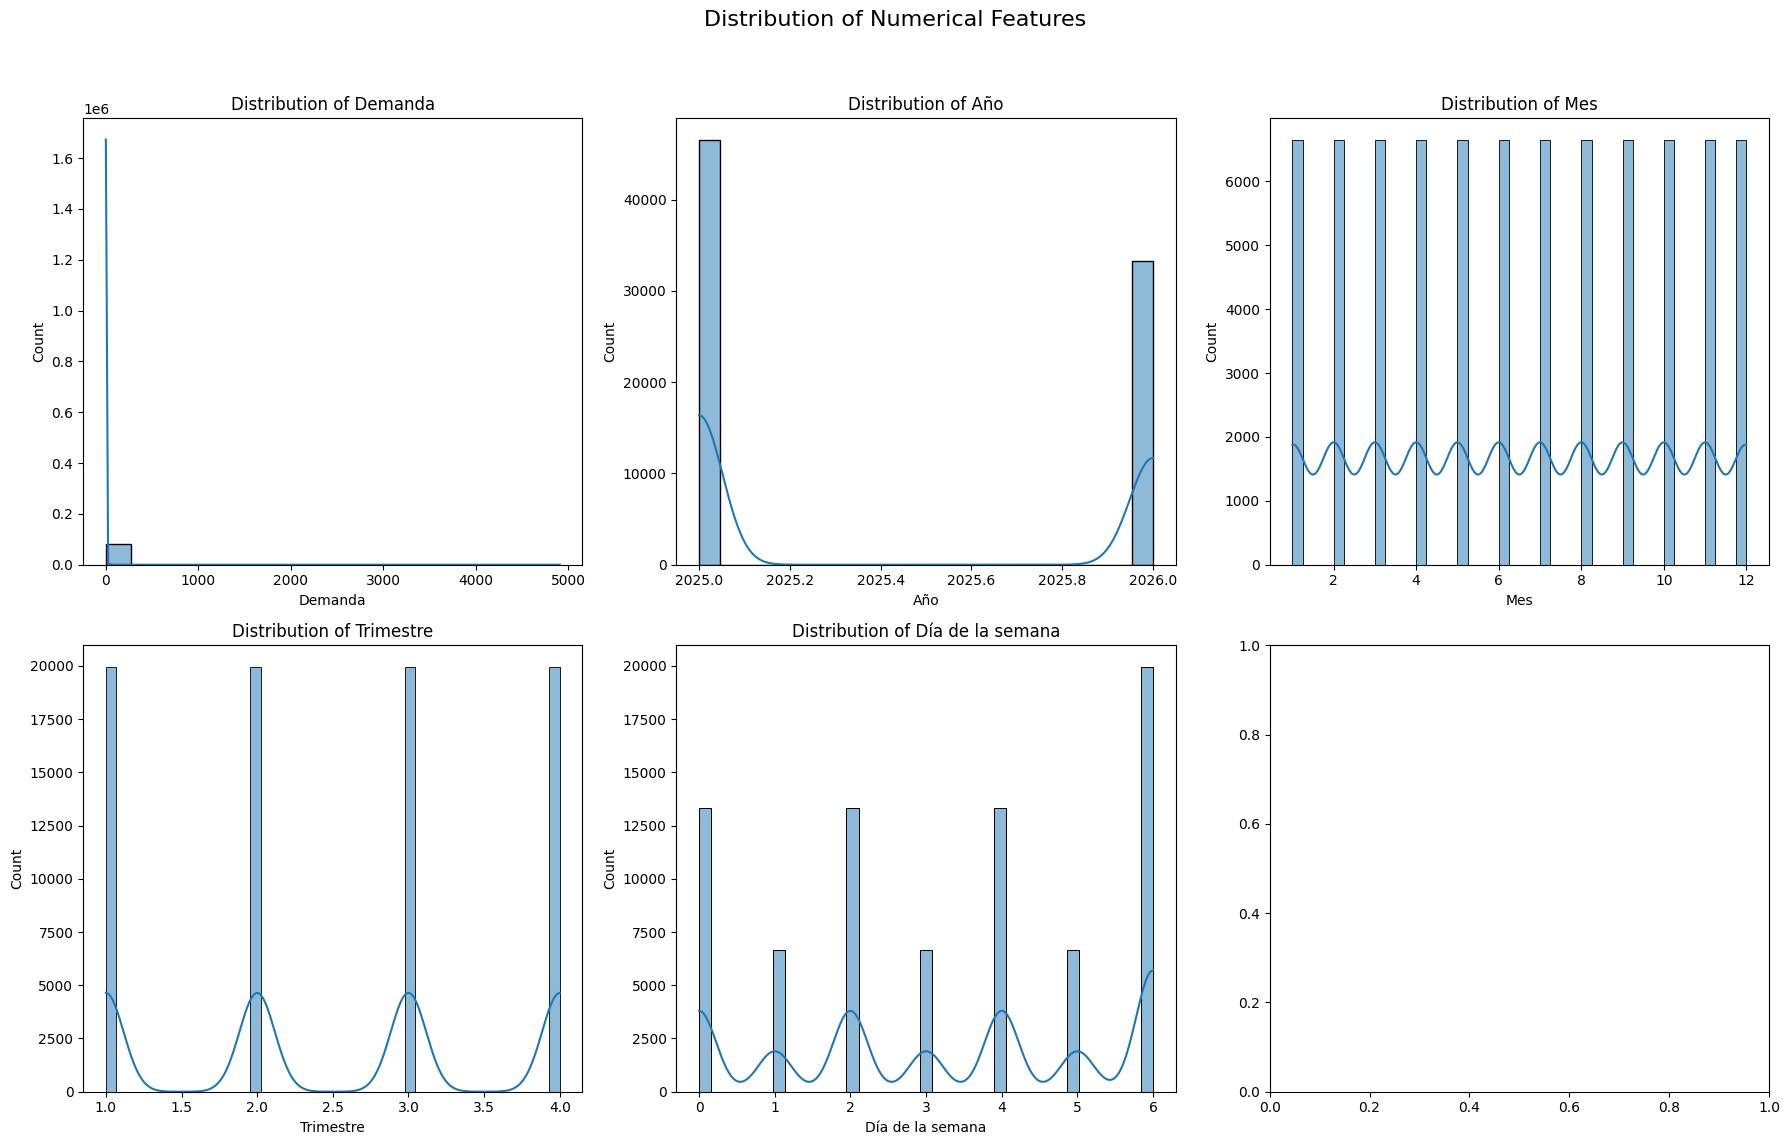

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.suptitle('Distribution of Numerical Features', fontsize=16)

sns.histplot(df_long['Demanda'], ax=axes[0, 0], kde=True)
axes[0, 0].set_title('Distribution of Demanda')

sns.histplot(df_long['Año'], ax=axes[0, 1], kde=True)
axes[0, 1].set_title('Distribution of Año')

sns.histplot(df_long['Mes'], ax=axes[0, 2], kde=True)
axes[0, 2].set_title('Distribution of Mes')

sns.histplot(df_long['Trimestre'], ax=axes[1, 0], kde=True)
axes[1, 0].set_title('Distribution of Trimestre')

sns.histplot(df_long['Día de la semana'], ax=axes[1, 1], kde=True)
axes[1, 1].set_title('Distribution of Día de la semana')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Reasoning**:
Generate box plots for the numerical features to visualize their distributions and identify outliers.



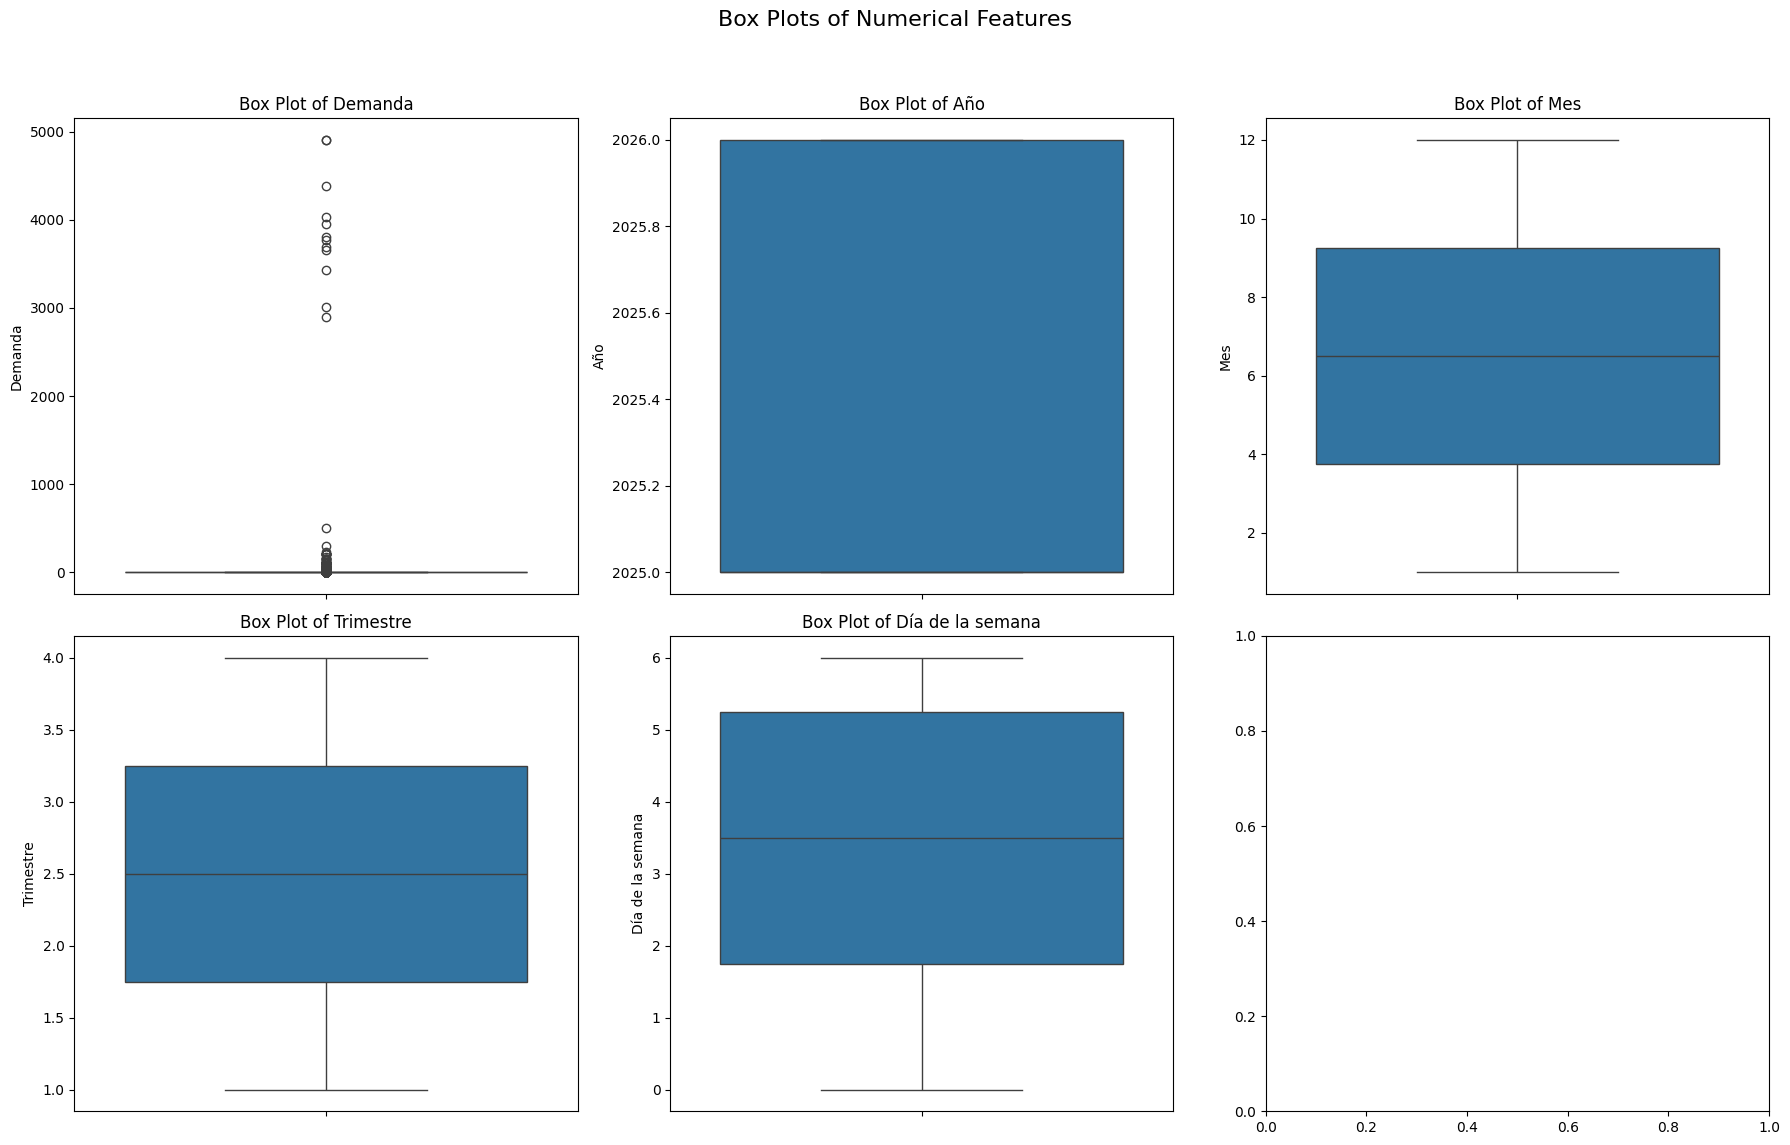

In [30]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.suptitle('Box Plots of Numerical Features', fontsize=16)

sns.boxplot(y=df_long['Demanda'], ax=axes[0, 0])
axes[0, 0].set_title('Box Plot of Demanda')

sns.boxplot(y=df_long['Año'], ax=axes[0, 1])
axes[0, 1].set_title('Box Plot of Año')

sns.boxplot(y=df_long['Mes'], ax=axes[0, 2])
axes[0, 2].set_title('Box Plot of Mes')

sns.boxplot(y=df_long['Trimestre'], ax=axes[1, 0])
axes[1, 0].set_title('Box Plot of Trimestre')

sns.boxplot(y=df_long['Día de la semana'], ax=axes[1, 1])
axes[1, 1].set_title('Box Plot of Día de la semana')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Analyze Categorical Features

### Subtask:
Investigate the unique values and their frequencies for categorical columns ('Asesor', 'Cliente ajustado', 'Marca', 'Articulo') in `df_long`. This will involve creating count plots to visualize the distribution of each categorical feature.


**Reasoning**:
As instructed, I will print the unique values and their counts for the categorical columns in `df_long` to start the analysis of categorical features.



In [31]:
print('Unique values and their counts for categorical columns in df_long:')
categorical_cols_long = ['Asesor', 'Cliente ajustado', 'Marca', 'Articulo']
for col in categorical_cols_long:
    print(f"\nColumn: {col}")
    print(df_long[col].value_counts(dropna=False))

Unique values and their counts for categorical columns in df_long:

Column: Asesor
Asesor
MAURICIO PRADA        8544
CESAR REYES           7320
JOSE CARO             7296
GUSTAVO JARAMILLO     6612
VICTOR GARCIA         6252
EDUARDO IBAÑEZ        5376
JUAN ESTEBAN MARIN    4512
JUAN AVELLA           4356
FAVIAN SALCEDO        4308
JAIME AMAYA           3588
CARLOS MONSERRATE     2916
ALEXANDER SERNA       2724
VACANTE - BOGOTA      2712
ANGELA GARCIA         2364
FRANCY SANTANILLA     2040
ANDRES MORANTES       1968
EDWIN RONCANCIO       1932
PAOLA CEDEÑO          1848
DIEGO OSUNA           1548
DIANA ROMERO           708
ADMINISTRACION         600
MILLER USAQUEN         228
VACANTE - ACOTADO       60
INACTIVO                36
VACANTE - FLOTAS        12
Total                   12
Name: count, dtype: int64

Column: Cliente ajustado
Cliente ajustado
Cliente 646    2004
Cliente 421    1812
Cliente 192     984
Cliente 471     960
Cliente 738     948
               ... 
Cliente 725      12

**Reasoning**:
As instructed by the subtask, I will now create count plots for the categorical columns ('Asesor', 'Cliente ajustado', 'Marca', 'Articulo') in `df_long` to visualize their distributions.



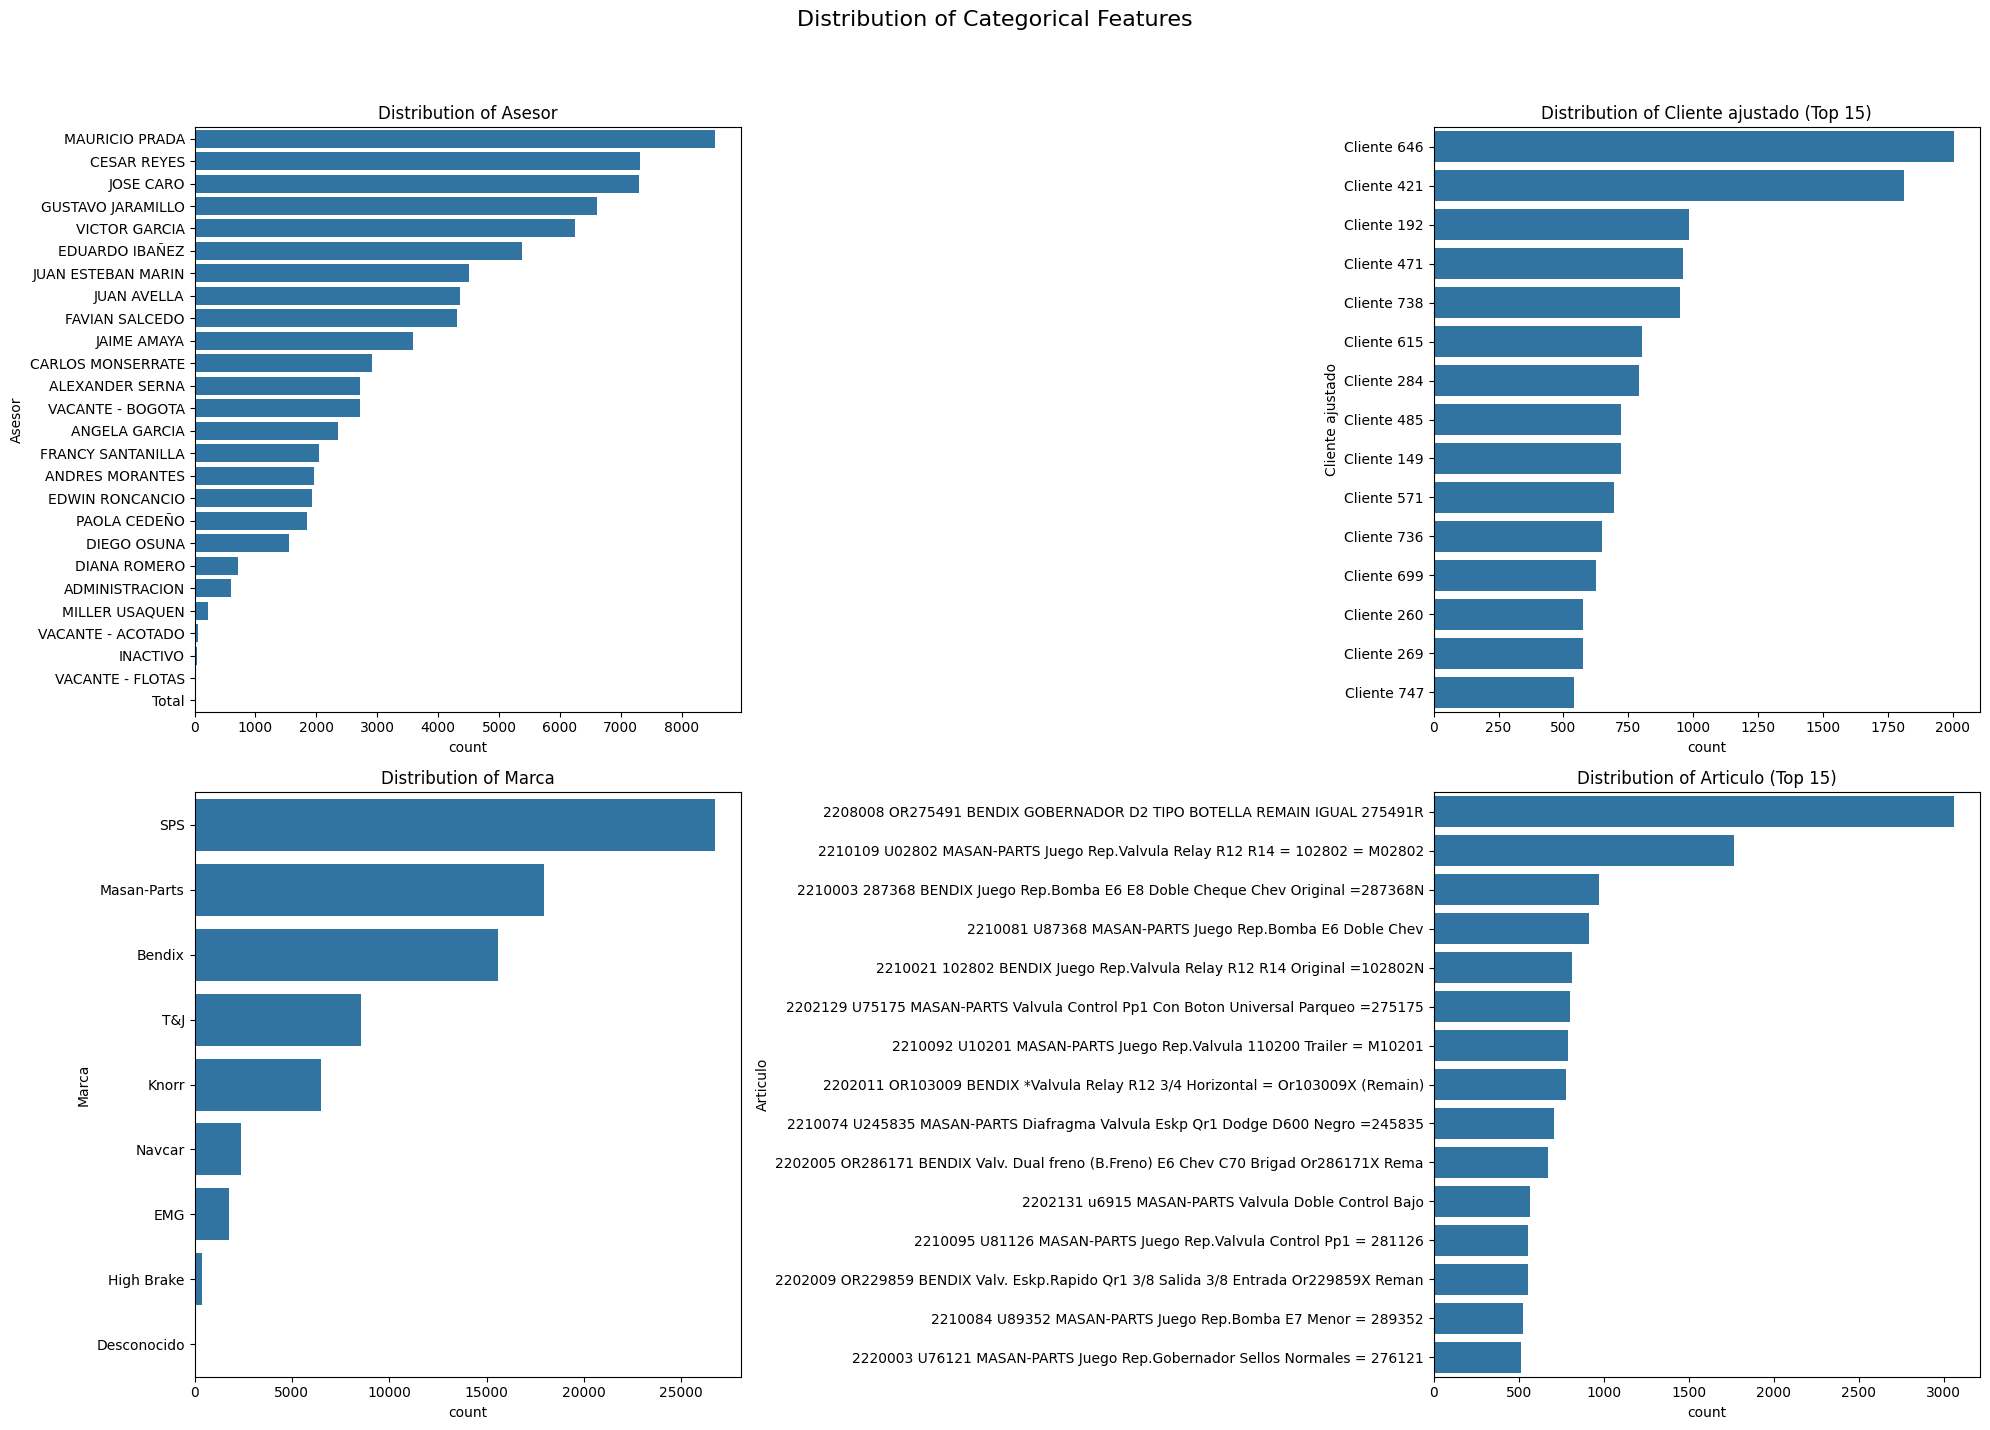

In [32]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 15))
fig.suptitle('Distribution of Categorical Features', fontsize=16)

sns.countplot(y=df_long['Asesor'], ax=axes[0, 0], order=df_long['Asesor'].value_counts().index)
axes[0, 0].set_title('Distribution of Asesor')

sns.countplot(y=df_long['Cliente ajustado'], ax=axes[0, 1], order=df_long['Cliente ajustado'].value_counts().head(15).index) # Limiting to top 15 for readability
axes[0, 1].set_title('Distribution of Cliente ajustado (Top 15)')

sns.countplot(y=df_long['Marca'], ax=axes[1, 0], order=df_long['Marca'].value_counts().index)
axes[1, 0].set_title('Distribution of Marca')

sns.countplot(y=df_long['Articulo'], ax=axes[1, 1], order=df_long['Articulo'].value_counts().head(15).index) # Limiting to top 15 for readability
axes[1, 1].set_title('Distribution of Articulo (Top 15)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Explore Time-based Trends

### Subtask:
Analyze the trends and seasonality of 'Demanda' over time using the 'Fecha' column and the engineered time features.


**Reasoning**:
I need to create a line plot of total 'Demanda' over time. This involves grouping the DataFrame by 'Fecha' and summing the 'Demanda', then using matplotlib/seaborn to plot the aggregated data. I will then set the title and labels for better readability.



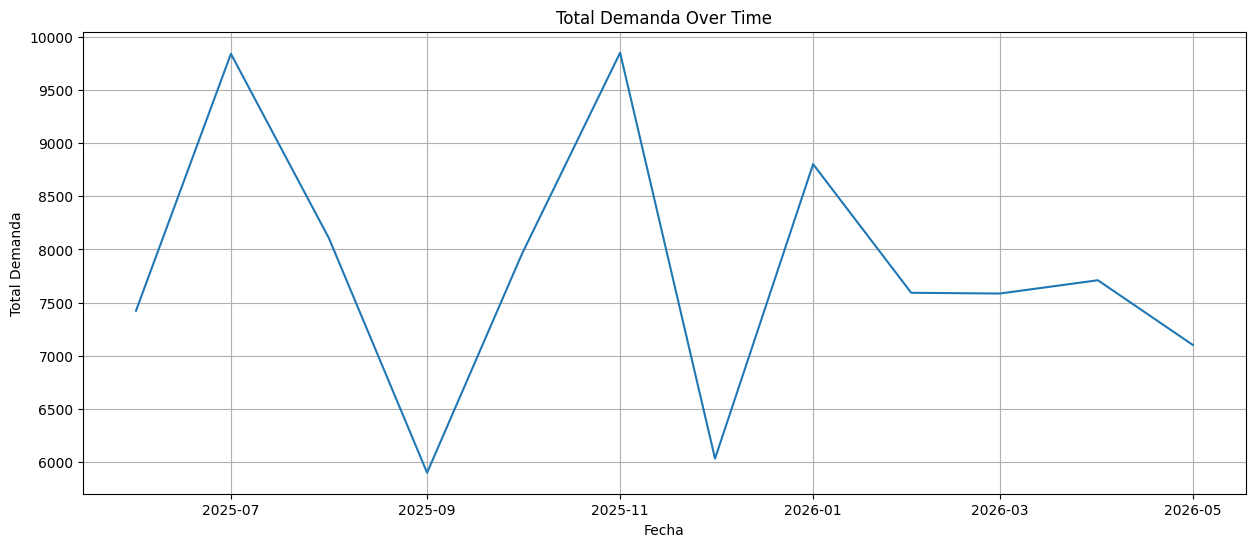

In [33]:
demand_over_time = df_long.groupby('Fecha')['Demanda'].sum().reset_index()

plt.figure(figsize=(15, 6))
sns.lineplot(x='Fecha', y='Demanda', data=demand_over_time)
plt.title('Total Demanda Over Time')
plt.xlabel('Fecha')
plt.ylabel('Total Demanda')
plt.grid(True)
plt.show()


**Reasoning**:
I need to visualize the average demand by month to identify any monthly seasonality. I will group the DataFrame by 'Mes' and calculate the mean of 'Demanda', then create a bar plot of this aggregated data.



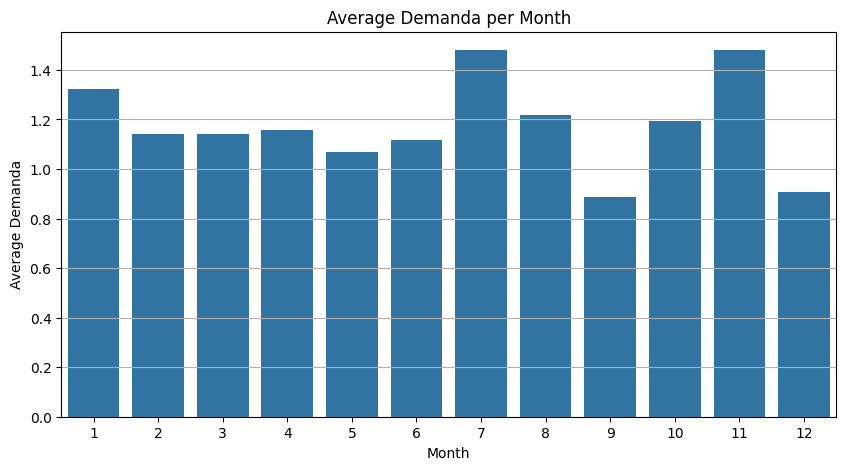

In [34]:
avg_demand_per_month = df_long.groupby('Mes')['Demanda'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='Mes', y='Demanda', data=avg_demand_per_month)
plt.title('Average Demanda per Month')
plt.xlabel('Month')
plt.ylabel('Average Demanda')
plt.xticks(ticks=range(0, 12), labels=[f'{i+1}' for i in range(12)]) # Label months 1-12
plt.grid(axis='y')
plt.show()

**Reasoning**:
I need to visualize the average demand by quarter and by day of the week to identify any quarterly or weekly seasonality. I will group the DataFrame by 'Trimestre' and 'Día de la semana' respectively, calculate the mean of 'Demanda', and then create bar plots of this aggregated data.



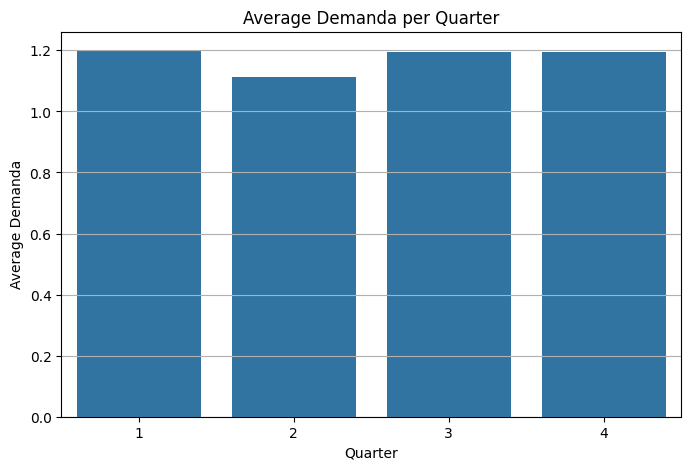

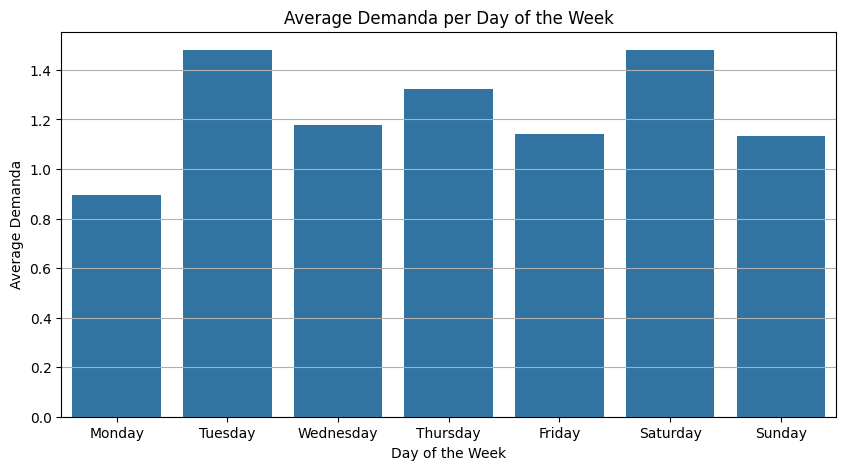

In [35]:
avg_demand_per_quarter = df_long.groupby('Trimestre')['Demanda'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='Trimestre', y='Demanda', data=avg_demand_per_quarter)
plt.title('Average Demanda per Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average Demanda')
plt.grid(axis='y')
plt.show()

avg_demand_per_weekday = df_long.groupby('Día de la semana')['Demanda'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='Día de la semana', y='Demanda', data=avg_demand_per_weekday)
plt.title('Average Demanda per Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Demanda')
plt.xticks(ticks=range(7), labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.grid(axis='y')
plt.show()

## Investigate Relationships between Features and Demand

### Subtask:
Explore the relationships between the categorical features ('Asesor', 'Cliente ajustado', 'Marca', 'Articulo') and 'Demanda'. This will involve creating bar plots to show the average 'Demanda' for different categories within each feature, and identifying top performers or categories with high demand.


**Reasoning**:
I need to calculate the average demand per 'Asesor' and visualize it with a bar plot, as per the first instruction of the subtask. This will help identify which advisors are associated with higher or lower average demand.



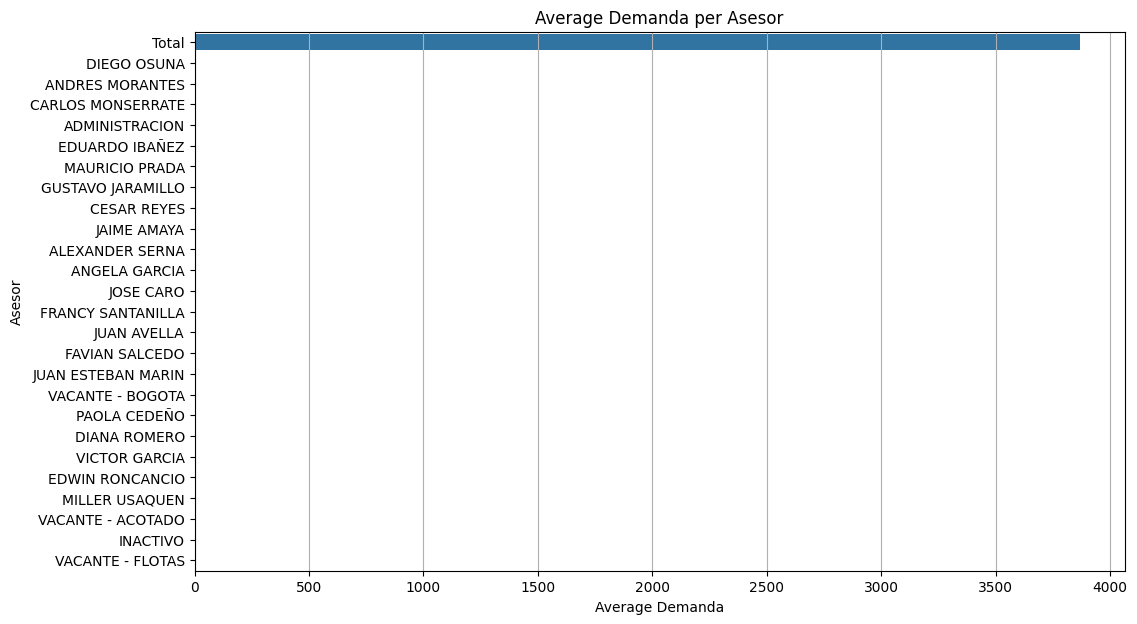

In [36]:
avg_demand_per_asesor = df_long.groupby('Asesor')['Demanda'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Demanda', y='Asesor', data=avg_demand_per_asesor)
plt.title('Average Demanda per Asesor')
plt.xlabel('Average Demanda')
plt.ylabel('Asesor')
plt.grid(axis='x')
plt.show()

**Reasoning**:
I need to calculate the average demand per 'Cliente ajustado' and visualize it with a bar plot. This will help identify which clients are associated with higher or lower average demand, focusing on the top 15 for readability.



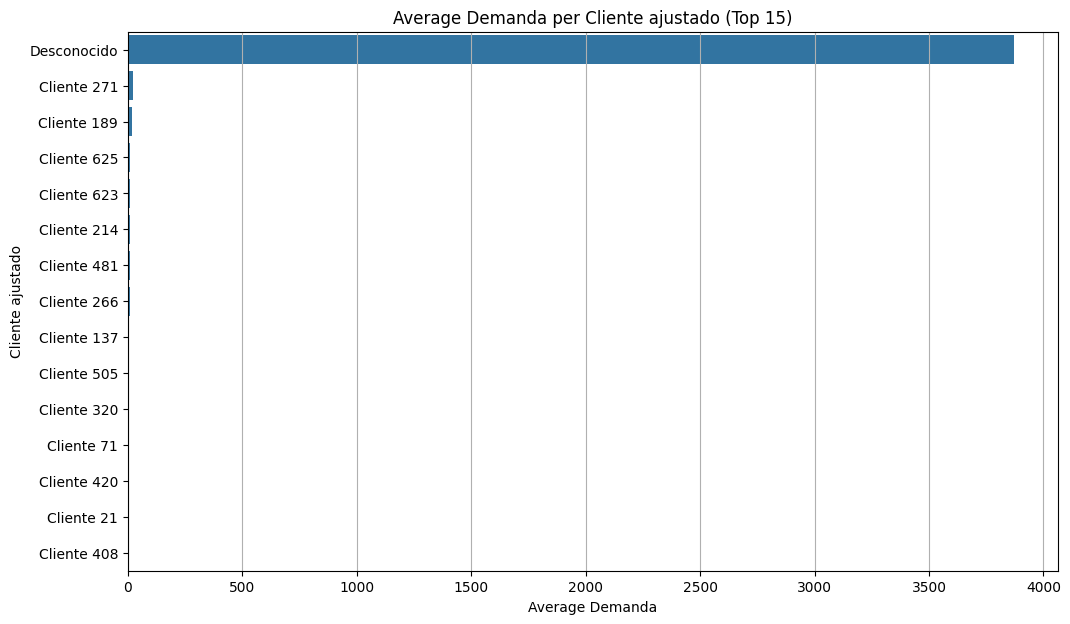

In [37]:
avg_demand_per_cliente = df_long.groupby('Cliente ajustado')['Demanda'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Demanda', y='Cliente ajustado', data=avg_demand_per_cliente.head(15)) # Limiting to top 15 for readability
plt.title('Average Demanda per Cliente ajustado (Top 15)')
plt.xlabel('Average Demanda')
plt.ylabel('Cliente ajustado')
plt.grid(axis='x')
plt.show()

**Reasoning**:
I need to calculate the average demand per 'Marca' and visualize it with a bar plot. This will help identify which brands are associated with higher or lower average demand.



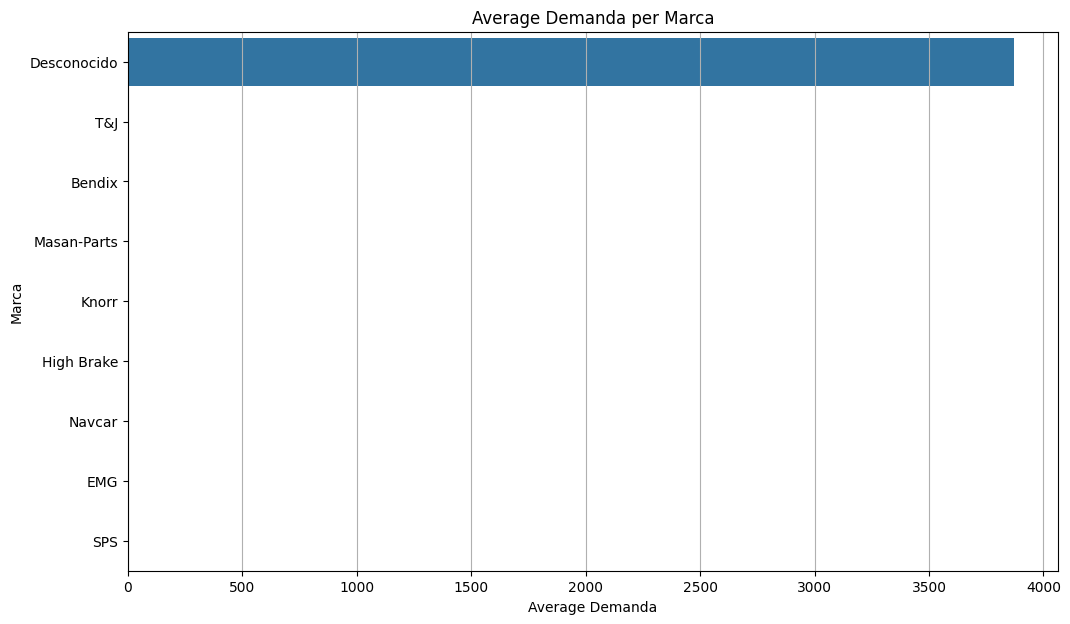

In [38]:
avg_demand_per_marca = df_long.groupby('Marca')['Demanda'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Demanda', y='Marca', data=avg_demand_per_marca)
plt.title('Average Demanda per Marca')
plt.xlabel('Average Demanda')
plt.ylabel('Marca')
plt.grid(axis='x')
plt.show()

**Reasoning**:
I need to calculate the average demand per 'Articulo' and visualize it with a bar plot. This will help identify which articles are associated with higher or lower average demand, focusing on the top 15 for readability.



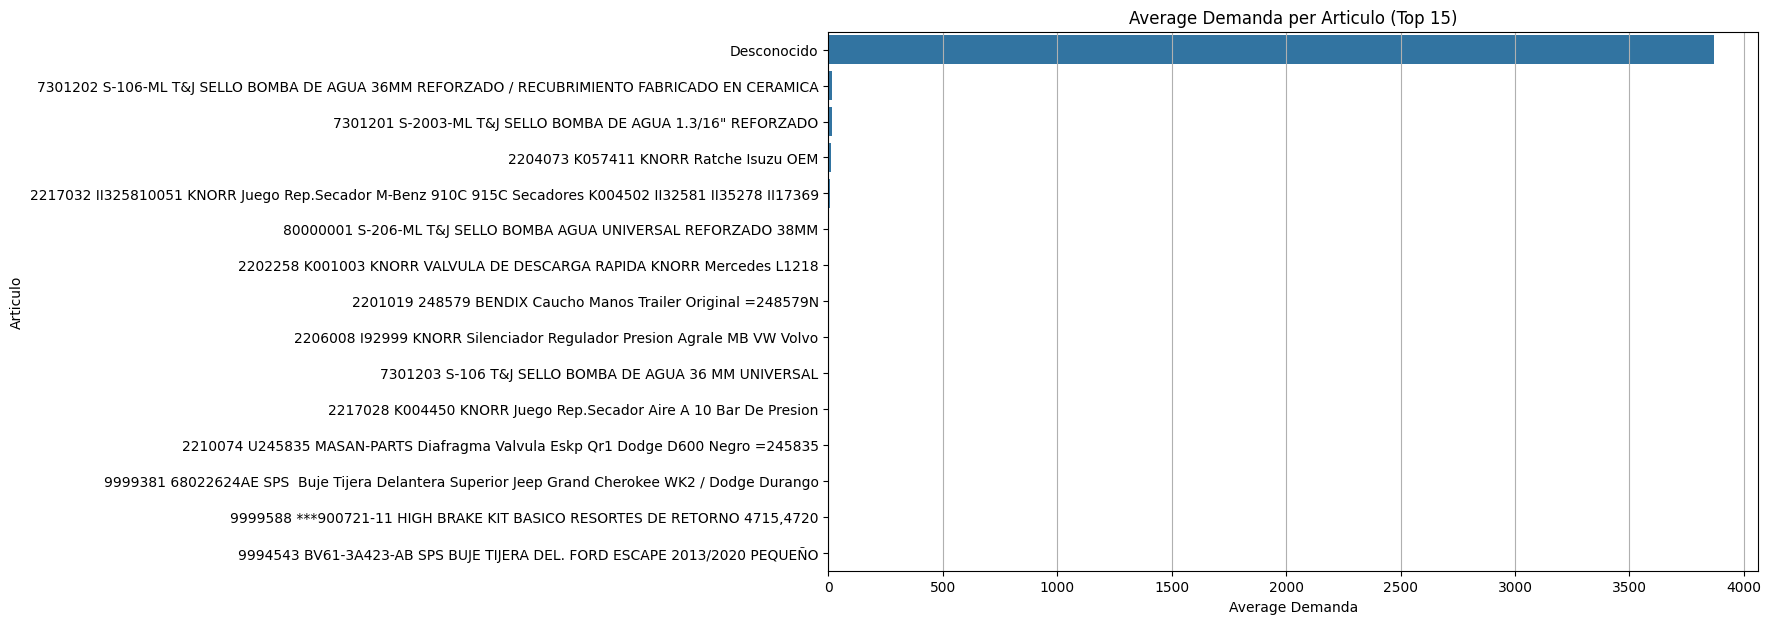

In [39]:
avg_demand_per_articulo = df_long.groupby('Articulo')['Demanda'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Demanda', y='Articulo', data=avg_demand_per_articulo.head(15)) # Limiting to top 15 for readability
plt.title('Average Demanda per Articulo (Top 15)')
plt.xlabel('Average Demanda')
plt.ylabel('Articulo')
plt.grid(axis='x')
plt.show()

## Correlation Analysis

### Subtask:
If applicable, calculate and visualize the correlation matrix for numerical features to understand linear relationships. This will involve creating a heatmap of the correlation matrix for numerical columns.


**Reasoning**:
I need to calculate the correlation matrix for the numerical columns and then visualize it using a heatmap.



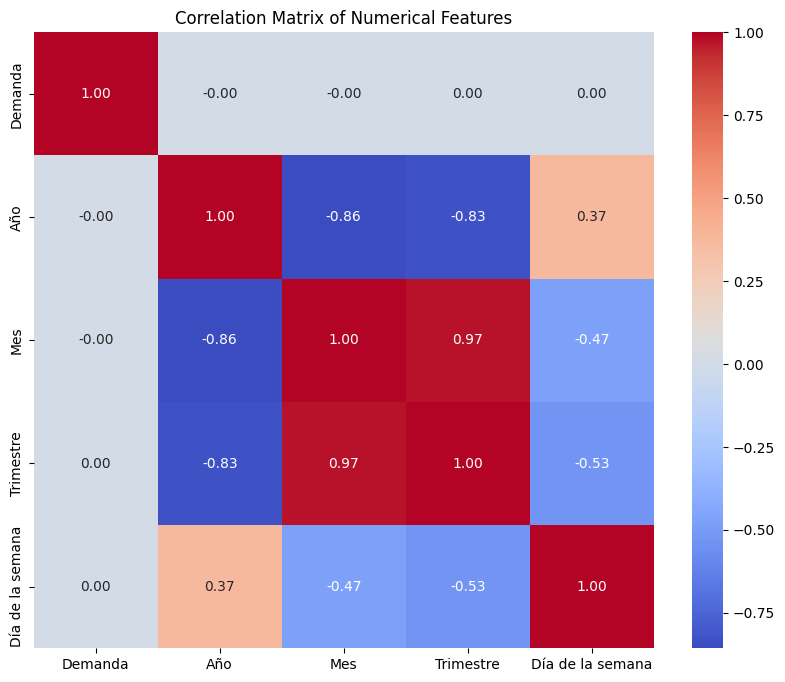

In [40]:
numerical_cols = ['Demanda', 'Año', 'Mes', 'Trimestre', 'Día de la semana']
correlation_matrix = df_long[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Final Task

### Subtask:
Summarize the key findings from the EDA, highlight any insights gained, and discuss the implications for the demand forecasting model development.


```markdown
# Summary of Exploratory Data Analysis (EDA) and Implications for Demand Forecasting

This EDA aimed to understand the `df_long` dataset, which contains demand data across various categorical features and time periods, to inform the development of a demand forecasting model.

## Key Findings:

### 1. Data Structure and Missing Values:
*   The initial `df` DataFrame contained `object` type categorical features ('Asesor', 'Cliente ajustado', 'Marca', 'Articulo') and `float64` type monthly demand columns ('6-2025' to '5-2026').
*   A few missing values were identified in 'Cliente ajustado', 'Marca', and 'Articulo' (1 entry each), which were successfully filled with 'Desconocido'.
*   The monthly demand columns had a very high percentage of missing values (83% to 88%), which were subsequently handled by transforming the data into a long format (`df_long`) and filling `NaN` demand values with 0.

### 2. Numerical Feature Analysis:
*   **Demanda:** The 'Demanda' column is highly skewed, with a large concentration of zero values and a maximum value of 4909, indicating infrequent but sometimes very high demand events. This suggests a need for models robust to sparse data or a zero-inflated modeling approach.
*   **Time-based Features ('Año', 'Mes', 'Trimestre', 'Día de la semana'):** These features were successfully engineered from the 'Fecha' column. Their distributions are as expected for time components over a ~1-year period.

### 3. Categorical Feature Analysis:
*   **Asesor:** Features a diverse distribution of advisors, with some having significantly more entries (e.g., MAURICIO PRADA) than others. A special 'Total' category was noted with very high average demand, likely an aggregation.
*   **Cliente ajustado & Articulo:** Both show high cardinality (755 unique clients, 988 unique articles). A few clients/articles dominate the counts. The 'Desconocido' categories also exhibited very high average demand, suggesting they may represent aggregated or unassigned sales.
*   **Marca:** 'SPS', 'Masan-Parts', and 'Bendix' are the most frequent brands, indicating their prominence in the dataset. 'Desconocido' brand also showed high average demand.

### 4. Time-based Trends:
*   **Total Demand Over Time:** The line plot showed fluctuations, with peaks in July and November 2025, and January 2026, suggesting seasonal patterns.
*   **Average Demand per Month:** Clear monthly seasonality was observed, with highest average demands in July and November, and lowest in September and December.
*   **Average Demand per Quarter:** Relatively consistent average demand across quarters, with slight variations.
*   **Average Demand per Day of the Week:** Weekly seasonality is present, with highest average demand on Tuesdays and Saturdays, and lowest on Mondays and Sundays.

### 5. Relationships between Features and Demand:
*   Significant variations in average demand were observed across different categories of 'Asesor', 'Cliente ajustado', 'Marca', and 'Articulo'. Some specific items, clients, and brands are consistently associated with higher average demand. The 'Desconocido' and 'Total' categories across different features consistently showed extremely high average demand, indicating they need special handling or further investigation as they are likely aggregations.

### 6. Correlation Analysis:
*   Very low linear correlation was found between 'Demanda' and the time-based numerical features ('Año', 'Mes', 'Trimestre', 'Día de la semana'). This suggests that linear models alone may not capture the complex relationships, and non-linear models or advanced feature engineering (e.g., interaction terms, embeddings) will be crucial.

## Insights for Demand Forecasting Strategy:

*   **Sparsity and Zero Demand:** The prevalence of zero demand and the skewed distribution of 'Demanda' indicate that a significant portion of items/client combinations do not have sales in every period. Forecasting models must be capable of handling this sparsity effectively, possibly by predicting the probability of demand first, and then the quantity, or using models robust to many zeros.
*   **Strong Seasonality:** Distinct monthly and weekly seasonal patterns are evident. These patterns must be explicitly captured through appropriate feature engineering (e.g., one-hot encoding months/days of the week, Fourier series) or by using time-series models that inherently handle seasonality (e.g., Prophet).
*   **High Cardinality Categorical Features:** 'Articulo' and 'Cliente ajustado' have many unique values. Direct one-hot encoding could lead to a very high-dimensional feature space. Techniques like target encoding, embeddings, or grouping less frequent categories might be necessary to manage these features effectively.
*   **Key Drivers of Demand:** Certain advisors, clients, brands, and articles consistently show higher average demand. These are critical features for the model and should be well-represented.
*   **

# Task
The user has provided a DataFrame named `df` containing sales or demand data across different months (6-2025 to 5-2026), along with categorical features like 'Asesor', 'Cliente ajustado', 'Marca', and 'Articulo'. The goal is to analyze this dataset to define a project construct for a forecasting task. This involves understanding the DataFrame's structure, identifying key variables, proposing suitable machine learning models, and outlining their advantages and disadvantages.

# Task
The user has provided a DataFrame named `df` containing sales or demand data across different months (6-2025 to 5-2026), along with categorical features like 'Asesor', 'Cliente ajustado', 'Marca', and 'Articulo'. The goal is to analyze this dataset to define a project construct for a forecasting task. This involves understanding the DataFrame's structure, identifying key variables, proposing suitable machine learning models, and outlining their advantages and disadvantages.

## Review Relevant EDA Findings

### Subtask:
Reiterate the key findings from the EDA that are most relevant to selecting a machine learning model. This includes observations on 'Demanda' distribution (sparsity, zeros), seasonality, categorical feature cardinality, and correlations.


### Key EDA Findings for Model Selection

Based on the Exploratory Data Analysis, several key findings are particularly relevant for selecting an appropriate machine learning model for demand forecasting:

1.  **'Demanda' Distribution (Sparsity and Zeros):** The 'Demanda' variable exhibits significant sparsity, with a large concentration of zero values across the dataset. While the majority of entries are zero, there are occasional high demand events (maximum value of 4909). This indicates a highly skewed distribution, suggesting that a significant portion of item/client combinations do not have sales in every period. Models must be robust to sparse data and potentially address the zero-inflation.

2.  **Seasonality:** Clear seasonal patterns were observed:
    *   **Monthly Seasonality:** The total demand over time showed fluctuations with peaks in July and November 2025, and January 2026. The average demand per month further reinforced this, with highest averages in July and November, and lowest in September and December.
    *   **Weekly Seasonality:** The average demand per day of the week showed variations, with higher demand on Tuesdays and Saturdays, and lower demand on Mondays and Sundays.

3.  **Categorical Feature Cardinality:**
    *   **High Cardinality:** 'Cliente ajustado' (755 unique values) and 'Articulo' (988 unique values) are features with high cardinality. 'Asesor' also has a notable number of unique values (26), while 'Marca' has fewer (9).
    *   **'Desconocido'/'Total' Categories:** Placeholder categories like 'Desconocido' (for missing values in 'Cliente ajustado', 'Marca', 'Articulo') and 'Total' (in 'Asesor') consistently showed extremely high average demand. These likely represent aggregated or unassigned sales and will require special handling to prevent misleading model interpretations or overfitting.

4.  **Correlation Analysis:** The correlation matrix revealed very low linear correlations between 'Demanda' and the engineered time-based numerical features ('Año', 'Mes', 'Trimestre', 'Día de la semana'). This suggests that simple linear models would likely be insufficient, and non-linear models or advanced feature engineering (e.g., embeddings for categorical features, interaction terms) will be crucial to capture the complex relationships driving demand.

## Evaluate Tree-based Models

### Subtask:
Discuss the strengths and weaknesses of tree-based models (e.g., XGBoost, LightGBM) in the context of the EDA findings. Specifically, consider their ability to handle tabular data, non-linear relationships, and how they would incorporate categorical and time-based features.


### Evaluation of Tree-based Models (e.g., XGBoost, LightGBM)

#### Strengths in Context of EDA Findings:

1.  **Handling Tabular Data and Mixed Feature Types:** Tree-based models are inherently well-suited for tabular data, which is precisely the format of our `df_long` DataFrame, comprising both numerical (engineered time features, Demanda) and categorical (`Asesor`, `Cliente ajustado`, `Marca`, `Articulo`) features. They can process this mix of data types effectively without extensive manual preprocessing like scaling.

2.  **Capturing Non-linear Relationships:** The EDA's correlation analysis showed very low linear correlations between 'Demanda' and time-based numerical features. This strongly suggests that non-linear relationships are at play. Tree-based models excel at capturing such complex, non-linear interactions and higher-order dependencies between features without requiring explicit interaction term engineering. This is crucial for understanding how different `Articulo`/`Cliente ajustado` combinations, coupled with time, influence demand.

3.  **Robustness to Skewed 'Demanda' Distribution and Zeros:** The 'Demanda' variable is highly skewed with a large concentration of zero values. Tree-based models, particularly gradient boosting machines, can be robust to such distributions. They can handle the many zero entries (representing periods of no sales) and also learn from the occasional high demand events without being overly sensitive to outliers, which is a significant advantage over linear models that assume normally distributed errors.

4.  **Handling Categorical Features and Their Complex Relationships:** The EDA revealed significant variations in average demand across different categories of `Asesor`, `Cliente ajustado`, `Marca`, and `Articulo`. Tree-based models can implicitly learn hierarchical and interacting relationships between these categorical features, even with high cardinality, provided appropriate encoding strategies are applied. They can effectively segment the data based on these categories to model demand patterns specific to certain advisors, clients, brands, or articles.

5.  **Implicit Feature Selection and Interaction:** These models naturally perform a form of feature selection and can model feature interactions. For instance, an `Articulo`'s demand might behave differently for `Cliente ajustado` A versus `Cliente ajustado` B, and tree models can capture these nuances without us having to explicitly create `Articulo` x `Cliente ajustado` interaction features.

### Evaluation of Tree-based Models (e.g., XGBoost, LightGBM)

#### Weaknesses in Context of EDA Findings:

1.  **Requires Feature Engineering for Time:** As highlighted by the low linear correlations in the EDA, tree-based models do not inherently understand temporal dependencies. To capture the observed seasonality (monthly, weekly) and trends, manual feature engineering is essential. This includes creating lag features (e.g., demand from previous months), rolling statistics (e.g., moving averages), and explicit time components (e.g., month of year, day of week, which we've already engineered). Without this, the models would treat each time period as independent, missing crucial predictive signals.

2.  **Less Direct Interpretability for Complex Models:** While individual decision trees are highly interpretable, ensemble models like XGBoost and LightGBM, especially with many trees, become less transparent. It can be challenging to understand the exact reasoning behind a specific forecast, which might be a drawback if business stakeholders require highly interpretable models to justify decisions. This contrasts with the clear component-based interpretability offered by some traditional time series models like Prophet for trend and seasonality.

3.  **Potential for Overfitting with High Cardinality and Sparse Data:** Given the high cardinality of features like 'Cliente ajustado' and 'Articulo' (755 and 988 unique values, respectively), and the sparsity of the 'Demanda' variable, there is a risk of overfitting. If not properly regularized or if encoding strategies are not carefully chosen, the model might learn overly specific patterns from the training data that do not generalize well to unseen data. For instance, it might assign high importance to a rare `Articulo`/`Cliente ajustado` combination that had an unusually high demand in a single instance.

4.  **Handling 'Desconocido'/'Total' Categories:** The EDA revealed 'Desconocido' and 'Total' categories having extremely high average demands. While tree models can handle these as distinct categories, their impact might be disproportionately large or misleading if they truly represent aggregated data rather than specific entities. Special care would be needed during feature engineering or model interpretation to ensure these do not artificially inflate predictions for new, genuinely 'unknown' categories.

5.  **Sensitive to Encoding Choices for Categorical Features:** While robust to categorical features, the performance of tree-based models can be sensitive to the chosen encoding strategy (e.g., one-hot encoding, label encoding, target encoding, embeddings). Given the high cardinality, a suboptimal encoding method could either lead to a very sparse feature space (one-hot) or introduce artificial ordinality (label encoding) or target leakage (simple target encoding). Careful experimentation with various encoding techniques will be necessary.

## Evaluate Traditional Time Series Models

### Subtask:
Discuss the strengths and weaknesses of traditional time series models (e.g., ARIMA, Prophet) in the context of the EDA findings. Focus on their capacity to model seasonality and trends, and their limitations regarding direct use of high-cardinality categorical features.


### Evaluation of Traditional Time Series Models (e.g., ARIMA, Prophet)

#### Strengths in Context of EDA Findings:

1.  **Explicit Modeling of Seasonality and Trends:** The EDA clearly identified significant monthly and weekly seasonal patterns in 'Demanda', as well as overall temporal fluctuations. Traditional time series models like ARIMA and Prophet are specifically designed to explicitly capture and forecast these temporal components. Prophet, in particular, allows for flexible modeling of multiple seasonalities (yearly, weekly, daily, etc.) and trends, and can incorporate holiday effects, which is highly beneficial given the observed patterns.

2.  **Robustness to Missing Data and Outliers (Prophet):** The 'Demanda' variable, after transformation to long format, still has many zero values, which can be seen as a form of sparsity or missing sales events. Prophet is particularly robust to missing data in the time series itself and can handle outliers well, making it suitable for datasets with irregular demand patterns. ARIMA models might require more careful handling of missing values or imputation.

3.  **Interpretability of Temporal Components:** Models like Prophet offer high interpretability by decomposing the time series into trend, seasonal, and holiday components. This can provide valuable business insights into the underlying drivers of demand over time, making it easier to communicate forecasting results to stakeholders.

4.  **Foundation for Univariate Forecasting:** When the goal is to forecast an aggregated time series (e.g., total monthly demand across all products, or demand for a single high-volume product), these models provide a strong and well-understood framework for univariate forecasting, leveraging the inherent temporal autocorrelation.

### Evaluation of Traditional Time Series Models (e.g., ARIMA, Prophet)

#### Weaknesses in Context of EDA Findings:

1.  **Data Aggregation Requirement:** Traditional time series models generally cannot directly use the rich categorical features (`Asesor`, `Cliente ajustado`, `Marca`, `Articulo`) as direct inputs in their standard formulations. To apply these models, the data would need to be aggregated (e.g., total sales per month across all products) or modeled hierarchically, which adds complexity if granular forecasts for individual product/client combinations are desired.

2.  **Univariate Nature (ARIMA):** ARIMA models are fundamentally univariate. If the goal is to forecast demand for thousands of unique `Articulo`/`Cliente ajustado` combinations, fitting and managing a separate ARIMA model for each combination would be computationally prohibitive and impractical. While multivariate extensions exist (e.g., VARIMA), they often scale poorly with many series.

3.  **Limited Direct Use of External Regressors (ARIMA):** While some traditional time series models (like ARIMA with exogenous variables, or Prophet with extra regressors) can incorporate additional features, they are typically designed for a smaller number of continuous or binary regressors. Directly handling high-cardinality categorical features like 'Cliente ajustado' (755 unique values) or 'Articulo' (988 unique values) would require extensive one-hot encoding, leading to a very high-dimensional input space that can be problematic for these models.

4.  **Assumptions and Stationarity (ARIMA):** ARIMA models require the time series to be stationary (constant mean, variance, and autocorrelation over time). This often necessitates differencing the data, which can sometimes make interpretation more challenging. Prophet is more flexible in this regard but still assumes a consistent underlying process.

5.  **Lack of Item-Specific Cross-Effects:** These models primarily focus on the temporal dynamics of a single time series. They are not well-suited to capture complex interactions between different `Articulo`s, `Marca`s, or `Cliente ajustado`s that might influence demand (e.g., a promotion on one `Articulo` affecting sales of another). Tree-based models are much better at modeling such cross-sectional relationships.

## Propose Handling for High Cardinality and Zero Demand

### Subtask:
Suggest specific strategies for dealing with high-cardinality categorical features (e.g., target encoding, embeddings, grouping) and the skewed/zero-inflated 'Demanda' distribution, which will influence model choice and feature engineering.


### Strategies for Handling High-Cardinality Categorical Features

The EDA highlighted that 'Cliente ajustado' (755 unique values), 'Articulo' (988 unique values), and 'Asesor' (26 unique values) are categorical features with varying, but often high, cardinality. Effectively incorporating these into a model is crucial, as demand varies significantly across their categories.

1.  **Target Encoding (Mean Encoding):**
    *   **Description:** This technique replaces each categorical value with the mean of the target variable ('Demanda') for that category. For example, each 'Articulo' would be replaced by the average demand observed for that specific article.
    *   **Benefits:** It directly captures the relationship between the category and the target, reducing dimensionality while retaining predictive power. It's particularly effective for high-cardinality features where one-hot encoding would create too many columns.
    *   **Risks:** Susceptible to data leakage if not implemented carefully (e.g., using only training data for encoding, or k-fold target encoding) and can be prone to overfitting, especially for categories with few observations.
    *   **Justification:** Given the clear variations in `Average Demanda per Cliente ajustado`, `Average Demanda per Articulo`, and `Average Demanda per Asesor` observed in the EDA, target encoding would allow the model to learn these underlying demand patterns directly. It's a pragmatic choice for tree-based models.

2.  **Embeddings (for Deep Learning Models):**
    *   **Description:** Categorical embeddings transform high-dimensional categorical variables into lower-dimensional dense vector representations. Each unique category is mapped to a vector in an embedding space, where similar categories are closer together.
    *   **Benefits:** Can capture complex, non-linear relationships and similarities between categories that might not be obvious. They are very powerful for high-cardinality features, especially when combined with neural networks or other complex models. Reduces the dimensionality significantly compared to one-hot encoding.
    *   **Limitations:** Requires a deep learning framework and is less interpretable than target encoding. The effectiveness depends on the size of the dataset and the complexity of the relationships.
    *   **Justification:** While not directly applicable to traditional tree-based models, if a deep learning approach (e.g., neural networks for tabular data) were considered, embeddings would be an excellent way to handle 'Cliente ajustado' and 'Articulo' effectively, potentially uncovering latent relationships between different clients or articles.

3.  **Grouping Less Frequent Categories:**
    *   **Description:** For categories with very few occurrences (e.g., `Articulo`s or `Cliente ajustado`s appearing only once or twice), these can be grouped into a single 'Other' or 'Rare' category. This reduces the number of unique categories, making encoding more manageable and preventing models from learning patterns from statistically insignificant categories.
    *   **Benefits:** Simplifies the feature space, reduces noise, and can improve model generalization by treating rare categories uniformly. It's useful before applying one-hot encoding or target encoding to prevent issues with categories that have insufficient data.
    *   **Limitations:** Might lead to a loss of information if rare categories have distinct patterns that are masked by grouping. The threshold for

### Strategies for Handling High-Cardinality Categorical Features

The EDA highlighted that 'Cliente ajustado' (755 unique values), 'Articulo' (988 unique values), and 'Asesor' (26 unique values) are categorical features with varying, but often high, cardinality. Effectively incorporating these into a model is crucial, as demand varies significantly across their categories.

1.  **Target Encoding (Mean Encoding):**
    *   **Description:** This technique replaces each categorical value with the mean of the target variable ('Demanda') for that category. For example, each 'Articulo' would be replaced by the average demand observed for that specific article.
    *   **Benefits:** It directly captures the relationship between the category and the target, reducing dimensionality while retaining predictive power. It's particularly effective for high-cardinality features where one-hot encoding would create too many columns.
    *   **Risks:** Susceptible to data leakage if not implemented carefully (e.g., using only training data for encoding, or k-fold target encoding) and can be prone to overfitting, especially for categories with few observations.
    *   **Justification:** Given the clear variations in `Average Demanda per Cliente ajustado`, `Average Demanda per Articulo`, and `Average Demanda per Asesor` observed in the EDA, target encoding would allow the model to learn these underlying demand patterns directly. It's a pragmatic choice for tree-based models.

2.  **Embeddings (for Deep Learning Models):**
    *   **Description:** Categorical embeddings transform high-dimensional categorical variables into lower-dimensional dense vector representations. Each unique category is mapped to a vector in an embedding space, where similar categories are closer together.
    *   **Benefits:** Can capture complex, non-linear relationships and similarities between categories that might not be obvious. They are very powerful for high-cardinality features, especially when combined with neural networks or other complex models. Reduces the dimensionality significantly compared to one-hot encoding.
    *   **Limitations:** Requires a deep learning framework and is less interpretable than target encoding. The effectiveness depends on the size of the dataset and the complexity of the relationships.
    *   **Justification:** While not directly applicable to traditional tree-based models, if a deep learning approach (e.g., neural networks for tabular data) were considered, embeddings would be an excellent way to handle 'Cliente ajustado' and 'Articulo' effectively, potentially uncovering latent relationships between different clients or articles.

3.  **Grouping Less Frequent Categories:**
    *   **Description:** For categories with very few occurrences (e.g., `Articulo`s or `Cliente ajustado`s appearing only once or twice), these can be grouped into a single 'Other' or 'Rare' category. This reduces the number of unique categories, making encoding more manageable and preventing models from learning patterns from statistically insignificant categories.
    *   **Benefits:** Simplifies the feature space, reduces noise, and can improve model generalization by treating rare categories uniformly. It's useful before applying one-hot encoding or target encoding to prevent issues with categories that have insufficient data.
    *   **Limitations:** Might lead to a loss of information if rare categories have distinct patterns that are masked by grouping. The threshold for defining "rare" categories needs to be carefully determined based on business context and data analysis.

### Strategies for Handling Skewed/Zero-Inflated 'Demanda' Distribution

The 'Demanda' variable is highly skewed, with a significant concentration of zero values and occasional large positive values. This zero-inflation is common in demand forecasting and requires specific approaches.

1.  **Zero-Inflated Models:**
    *   **Description:** These models explicitly account for the two processes that generate data: one process determines whether the value is zero or non-zero (e.g., a logistic regression), and another process models the non-zero values (e.g., a Poisson or Negative Binomial regression). The final prediction is a combination of these two components.
    *   **Benefits:** Directly addresses the zero-inflation, which can lead to more accurate forecasts and better understanding of the underlying demand generation process. It can differentiate between 'no demand' and 'some demand'.
    *   **Justification:** Given the high number of zero demand entries, explicitly modeling the probability of *any* demand occurring, separate from the *quantity* of demand, is a robust approach. This can be implemented with custom loss functions in tree-based models or specialized statistical models.

2.  **Transformation of the Target Variable:**
    *   **Description:** Applying mathematical transformations (e.g., log transformation, square root transformation) to the 'Demanda' variable to reduce skewness and make its distribution more Gaussian-like. This is usually done for the non-zero values.
    *   **Benefits:** Can help models that assume normally distributed errors or linear relationships to perform better. It can stabilize variance.
    *   **Risks:** Interpretability of predictions becomes more complex as they need to be inverse-transformed back to the original scale. Log transformations cannot be directly applied to zero values, requiring a `log(1+x)` approach or separate handling.
    *   **Justification:** While tree-based models are robust to skewed distributions, transforming the target might still improve performance, especially if combined with other models or if we want to penalize errors on larger demands more effectively.

3.  **Two-Part Model Approach:**
    *   **Description:** Similar to zero-inflated models, this involves building two separate models: one binary classification model to predict whether demand will be zero or non-zero, and another regression model to predict the quantity of demand *given that it is non-zero*. The final forecast is the product of the probability of non-zero demand and the predicted non-zero quantity.
    *   **Benefits:** Allows for specialized models to handle each aspect (presence vs. quantity), potentially improving overall accuracy. Tree-based models are excellent for both classification and regression tasks, making this approach feasible.
    *   **Justification:** This approach aligns well with the capabilities of gradient boosting models. For instance, an XGBoost classifier could predict demand presence, and an XGBoost regressor could predict the quantity for non-zero cases.

4.  **Specialized Loss Functions:**
    *   **Description:** Using custom loss functions during model training that are specifically designed for count data or skewed distributions, such as Poisson loss, Negative Binomial loss, or Mean Squared Logarithmic Error (MSLE).
    *   **Benefits:** These loss functions naturally account for the characteristics of count data and can be more appropriate than standard Mean Squared Error (MSE) when dealing with many zeros and a skewed positive distribution.
    *   **Justification:** Gradient boosting frameworks like XGBoost and LightGBM allow for custom objective functions, making this a powerful way to tailor the model directly to the 'Demanda' distribution without explicit transformations.

## Recommend Algorithm Type

### Subtask:
Based on the evaluation of model types and considerations for data characteristics, recommend the most appropriate type of machine learning algorithm(s) for the initial demand forecasting implementation, justifying the choice with insights from the EDA.


### Recommended Algorithm Type for Initial Demand Forecasting

Based on the detailed Exploratory Data Analysis (EDA) and the evaluation of different model types, **Tree-based Ensemble Models (e.g., XGBoost, LightGBM)** are recommended as the most appropriate algorithm type for the initial demand forecasting implementation.

#### Justification Linked to EDA Insights:

1.  **Non-linear Relationships and Feature Interactions:** The EDA revealed very low linear correlations between 'Demanda' and engineered time-based numerical features. This strongly suggests that non-linear relationships are dominant. Tree-based models inherently excel at capturing complex, non-linear interactions and higher-order dependencies between features (e.g., how demand for a specific `Articulo` might vary for different `Cliente ajustado` and `Mes`). This is a critical advantage over linear models.

2.  **Handling High-Cardinality Categorical Features:** The dataset contains high-cardinality categorical features such as `Cliente ajustado` (755 unique values) and `Articulo` (988 unique values). Tree-based models, when combined with appropriate encoding strategies like **Target Encoding (Mean Encoding)** or potentially **Categorical Embeddings** (if a deep learning component is introduced later), can effectively leverage these features without generating an unmanageably high-dimensional feature space, unlike one-hot encoding for traditional linear models or some time series models. The EDA showed significant variations in demand across these categories, making their inclusion crucial.

3.  **Robustness to Skewed and Zero-Inflated 'Demanda':** The 'Demanda' variable is highly skewed with a large concentration of zero values. Tree-based models, particularly gradient boosting machines, are robust to such distributions and are less sensitive to outliers than traditional linear models. Strategies like a **Two-Part Model Approach** (a classification model for demand presence and a regression model for quantity) or using **Specialized Loss Functions** (e.g., Poisson, Negative Binomial, MSLE) can be readily implemented within these frameworks to directly address the zero-inflation, leading to more accurate predictions for sparse demand data.

4.  **Implicit Feature Engineering for Temporal Aspects:** While tree models do not inherently understand temporal order, the EDA clearly identified strong monthly and weekly seasonality. By engineering explicit time-based features (`Año`, `Mes`, `Trimestre`, `Día de la semana`, and potentially lag features or rolling statistics), tree-based models can effectively learn and incorporate these seasonal and trend patterns. This approach allows them to capture seasonality for individual `Articulo`/`Cliente ajustado` combinations, which is crucial for granular forecasting.

5.  **Granular Forecasting Capability:** The project requires forecasting at a granular level (for specific `Articulo`, `Cliente ajustado`, `Marca`, and `Asesor` combinations). Tree-based models are well-suited for this, as they can directly model the demand for each unique combination based on its specific attributes and engineered time features, rather than requiring aggregation or managing thousands of individual time series models.

#### Why this approach is preferred over Traditional Time Series Models:

While traditional time series models like ARIMA or Prophet excel at explicitly modeling temporal dependencies and seasonality, they have significant limitations for this dataset:

*   **High-Cardinality Categorical Features:** They cannot directly incorporate the rich, high-cardinality categorical features (`Cliente ajustado`, `Articulo`) without extensive and potentially lossy aggregation or complex multi-variate extensions that scale poorly.
*   **Granularity Challenge:** To provide granular forecasts, one would need to fit and manage a separate time series model for each unique combination of `Articulo`/`Cliente ajustado`, which is computationally impractical and complex given the thousands of unique items and clients.
*   **Cross-Sectional Interactions:** Traditional time series models primarily focus on a single time series and are not designed to capture the complex interactions *between* different categorical features (e.g., how `Marca` might influence `Articulo` demand given a `Cliente ajustado`), which tree-based models handle naturally.

In summary, the flexibility of tree-based ensemble models to handle mixed data types, non-linearities, high-cardinality features, and sparse/zero-inflated targets, coupled with their ability to integrate engineered temporal features, makes them the most pragmatic and powerful choice for the initial demand forecasting project.

## Final Task

### Subtask:
Conclude the model selection process, summarizing the recommended algorithm and explaining the next steps for model development (e.g., feature engineering, model training, evaluation).
